In [1]:
import os
from sklearn.model_selection import train_test_split
from typing import Dict, List, Tuple
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import Sequence
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras import layers, models
from tensorflow.keras.metrics import AUC
import warnings
warnings.filterwarnings("ignore")

2026-02-03 19:39:41.685943: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770147582.156455      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770147582.319355      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770147583.330739      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770147583.330785      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770147583.330788      55 computation_placer.cc:177] computation placer alr

In [2]:
men_root = "/kaggle/input/brats-classification/MEN_dataset/MEN"
modality = "t1n"
target_slices = 8

cases_below_16 = []

for case_id in sorted(os.listdir(men_root)):
    case_path = os.path.join(men_root, case_id)
    if not os.path.isdir(case_path):
        continue

    mod_path = os.path.join(case_path, modality)
    if not os.path.isdir(mod_path):
        # If the modality folder is missing, treat as 0 slices
        n_slices = 0
    else:
        n_slices = sum(
            1 for f in os.listdir(mod_path)
            if f.lower().endswith(".png")
        )

    if n_slices < target_slices:
        cases_below_16.append((case_id, n_slices))

print(f"Total MEN cases: {len([d for d in os.listdir(men_root) if os.path.isdir(os.path.join(men_root, d))])}")
print(f"Cases with < {target_slices} t1n slices: {len(cases_below_16)}\n")

print("Cases with fewer than 16 t1n slices:")
for cid, n in cases_below_16:
    print(f"{cid}: {n} slices")


Total MEN cases: 225
Cases with < 8 t1n slices: 26

Cases with fewer than 16 t1n slices:
BraTS-MEN-00026-000: 1 slices
BraTS-MEN-00069-000: 1 slices
BraTS-MEN-00094-000: 6 slices
BraTS-MEN-00108-004: 4 slices
BraTS-MEN-00108-005: 5 slices
BraTS-MEN-00132-000: 7 slices
BraTS-MEN-00141-000: 1 slices
BraTS-MEN-00157-000: 1 slices
BraTS-MEN-00173-000: 4 slices
BraTS-MEN-00177-000: 5 slices
BraTS-MEN-00183-000: 5 slices
BraTS-MEN-00192-000: 6 slices
BraTS-MEN-00199-000: 7 slices
BraTS-MEN-00233-000: 1 slices
BraTS-MEN-00244-000: 1 slices
BraTS-MEN-00281-000: 3 slices
BraTS-MEN-00356-000: 7 slices
BraTS-MEN-00358-000: 5 slices
BraTS-MEN-00420-000: 3 slices
BraTS-MEN-00457-000: 1 slices
BraTS-MEN-00478-000: 2 slices
BraTS-MEN-00481-000: 6 slices
BraTS-MEN-00487-000: 6 slices
BraTS-MEN-00496-000: 6 slices
BraTS-MEN-00502-000: 6 slices
BraTS-MEN-00514-000: 1 slices


In [4]:
# Roots for each class
ROOT_GLI = "/kaggle/input/brats-classification/GLI_dataset/GLI"
ROOT_METS = "/kaggle/input/brats-classification/METS_dataset/METS"
ROOT_MEN = "/kaggle/input/brats-classification/MEN_dataset/MEN"

MODALITIES = ["t1n", "t1c", "t2w", "t2f"]

CLASS_ROOTS = {
    0: ("GLI", ROOT_GLI),
    1: ("METS", ROOT_METS),
    2: ("OTHER", ROOT_MEN),   # MEN is mapped to label 2 (OTHER)
}

def list_pngs_sorted(folder: str) -> List[str]:
    """Return full paths of .png files in a folder, sorted by name."""
    if not os.path.isdir(folder):
        return []
    files = [f for f in os.listdir(folder) if f.lower().endswith(".png")]
    files.sort()
    return [os.path.join(folder, f) for f in files]

# case_index: case_id -> dict with class_label and per-modality slice paths
case_index: Dict[str, dict] = {}

for class_label, (class_name, root) in CLASS_ROOTS.items():
    for case_id in sorted(os.listdir(root)):
        case_path = os.path.join(root, case_id)
        if not os.path.isdir(case_path):
            continue

        per_mod_paths = {}
        for mod in MODALITIES:
            mod_path = os.path.join(case_path, mod)
            per_mod_paths[mod] = list_pngs_sorted(mod_path)

        # store entry
        global_case_id = f"{class_name}:{case_id}"  # avoid collisions across classes
        case_index[global_case_id] = {
            "class_label": class_label,
            "class_name": class_name,
            "root": root,
            "case_dir": case_id,
            "modalities": per_mod_paths,
        }

print(f"Total cases indexed: {len(case_index)}")
print("Example entry:")
first_key = next(iter(case_index.keys()))
print(first_key)
for k, v in case_index[first_key].items():
    if k == "modalities":
        print("  modalities:", {m: len(v[m]) for m in MODALITIES})
    else:
        print(" ", k, "=", v)

Total cases indexed: 1780
Example entry:
GLI:BraTS-GLI-00000-000
  class_label = 0
  class_name = GLI
  root = /kaggle/input/brats-classification/GLI_dataset/GLI
  case_dir = BraTS-GLI-00000-000
  modalities: {'t1n': 10, 't1c': 10, 't2w': 10, 't2f': 10}


In [5]:
# Per-class rules: (min_slices_per_modality, target_slices_per_modality)
CLASS_RULES = {
    0: {"min": 8, "target": 10},  # GLI
    1: {"min": 9, "target": 16},  # METS
    2: {"min": 8, "target": 16},  # OTHER (MEN)
}

def build_slice_plan_for_case(case_entry):
    """
    For a single case, decide if it passes QC and
    return planned slice indices per modality.

    Returns:
      (keep_case, slice_indices_per_modality)
      - keep_case = False if case must be dropped.
      - slice_indices_per_modality: dict[mod] -> list of indices (0-based).
    """
    label = case_entry["class_label"]
    rules = CLASS_RULES[label]
    min_req = rules["min"]
    target = rules["target"]

    planned = {}
    for mod, paths in case_entry["modalities"].items():
        n = len(paths)

        # QC: modality missing or too few slices
        if n < min_req:
            return False, {}

        # If already at target, just use all indices
        if n == target:
            planned[mod] = list(range(n))

        elif n > target:
            # You said no folder exceeds the class max,
            # so this should not happen; keep as safety (central crop).
            start = (n - target) // 2
            planned[mod] = list(range(start, start + target))

        else:
            # n between min_req and target: duplicate indices cyclically
            reps = (target + n - 1) // n  # ceil(target / n)
            idxs = (list(range(n)) * reps)[:target]
            planned[mod] = idxs

    return True, planned

# Build cleaned index and collect stats
clean_case_index = {}
dropped_cases = []

for case_id, entry in case_index.items():
    keep, plan = build_slice_plan_for_case(entry)
    if not keep:
        dropped_cases.append(case_id)
        continue

    new_entry = dict(entry)
    new_entry["slice_plan"] = plan  # per-modality index list
    clean_case_index[case_id] = new_entry

print(f"Total original cases: {len(case_index)}")
print(f"Cases kept after QC: {len(clean_case_index)}")
print(f"Cases dropped: {len(dropped_cases)}")

# Per-class case counts after QC
per_class_counts = {0: 0, 1: 0, 2: 0}
for entry in clean_case_index.values():
    per_class_counts[entry["class_label"]] += 1
print("Cases per class after QC:", per_class_counts)

# Quick check on one example
example_id = next(iter(clean_case_index.keys()))
ex = clean_case_index[example_id]
print("\nExample:", example_id)
print("  class_label:", ex["class_label"], "class_name:", ex["class_name"])
for mod in MODALITIES:
    print(f"  {mod}: original={len(ex['modalities'][mod])}, planned={len(ex['slice_plan'][mod])}")


Total original cases: 1780
Cases kept after QC: 1713
Cases dropped: 67
Cases per class after QC: {0: 1239, 1: 275, 2: 199}

Example: GLI:BraTS-GLI-00000-000
  class_label: 0 class_name: GLI
  t1n: original=10, planned=10
  t1c: original=10, planned=10
  t2w: original=10, planned=10
  t2f: original=10, planned=10


In [6]:
slice_samples = []  # list of (case_key, slice_idx, label)

for case_key, entry in clean_case_index.items():
    label = entry["class_label"]
    # we assume all modalities for a case share the same planned length
    # so we can take length from any modality, e.g. t1n
    planned_indices = entry["slice_plan"]["t1n"]
    num_slices = len(planned_indices)

    for local_idx in range(num_slices):
        # Instead of storing per-modality indices here,
        # we store just the position; we'll look up real indices later.
        slice_samples.append((case_key, local_idx, label))

print("Total slice-level samples:", len(slice_samples))

# Quick per-class slice counts
slice_counts_per_class = {0: 0, 1: 0, 2: 0}
for _, _, label in slice_samples:
    slice_counts_per_class[label] += 1
print("Slice counts per class (before any split or oversampling):", slice_counts_per_class)

# Sanity check on one sample
print("\nExample sample:", slice_samples[0])


Total slice-level samples: 19974
Slice counts per class (before any split or oversampling): {0: 12390, 1: 4400, 2: 3184}

Example sample: ('GLI:BraTS-GLI-00000-000', 0, 0)


In [7]:
# 1) Build arrays of case IDs and labels
case_ids = []
case_labels = []

for case_key, entry in clean_case_index.items():
    case_ids.append(case_key)
    case_labels.append(entry["class_label"])

case_ids = list(case_ids)
case_labels = list(case_labels)

# 2) First split: train (70%) vs temp (30%)
train_case_ids, temp_case_ids, train_labels, temp_labels = train_test_split(
    case_ids,
    case_labels,
    test_size=0.30,
    random_state=42,
    stratify=case_labels,
)

# 3) Second split: temp -> val (15%) and test (15%) overall
# temp is 30% of data; to get 15/15 we split 0.5/0.5
val_case_ids, test_case_ids, val_labels, test_labels = train_test_split(
    temp_case_ids,
    temp_labels,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels,
)

train_cases = set(train_case_ids)
val_cases = set(val_case_ids)
test_cases = set(test_case_ids)

print("Case counts after stratified split:")
print("  Train:", len(train_cases))
print("  Val  :", len(val_cases))
print("  Test :", len(test_cases))
print("  Total:", len(train_cases) + len(val_cases) + len(test_cases))

# 4) Map slice_samples to splits
train_slices = []
val_slices = []
test_slices = []

for sample in slice_samples:
    case_key, local_idx, label = sample
    if case_key in train_cases:
        train_slices.append(sample)
    elif case_key in val_cases:
        val_slices.append(sample)
    elif case_key in test_cases:
        test_slices.append(sample)
    else:
        raise ValueError("Case not found in any split: " + case_key)

print("\nSlice counts after split (before oversampling):")
print("  Train:", len(train_slices))
print("  Val  :", len(val_slices))
print("  Test :", len(test_slices))
print("  Total:", len(train_slices) + len(val_slices) + len(test_slices))

def count_slices_per_class(samples):
    counts = {0: 0, 1: 0, 2: 0}
    for _, _, lbl in samples:
        counts[lbl] += 1
    return counts

print("\nPer-class slice counts:")
print("  Train:", count_slices_per_class(train_slices))
print("  Val  :", count_slices_per_class(val_slices))
print("  Test :", count_slices_per_class(test_slices))


Case counts after stratified split:
  Train: 1199
  Val  : 257
  Test : 257
  Total: 1713

Slice counts after split (before oversampling):
  Train: 13982
  Val  : 2996
  Test : 2996
  Total: 19974

Per-class slice counts:
  Train: {0: 8670, 1: 3088, 2: 2224}
  Val  : {0: 1860, 1: 656, 2: 480}
  Test : {0: 1860, 1: 656, 2: 480}


In [8]:
def count_cases_per_class(case_set, case_index):
    counts = {0: 0, 1: 0, 2: 0}
    for case_key in case_set:
        lbl = case_index[case_key]["class_label"]
        counts[lbl] += 1
    return counts

train_case_counts = count_cases_per_class(train_cases, clean_case_index)
val_case_counts   = count_cases_per_class(val_cases, clean_case_index)
test_case_counts  = count_cases_per_class(test_cases, clean_case_index)

print("Case counts per class:")
print("  Train (GLI=0, METS=1, OTHER=2):", train_case_counts)
print("  Val   (GLI=0, METS=1, OTHER=2):", val_case_counts)
print("  Test  (GLI=0, METS=1, OTHER=2):", test_case_counts)


Case counts per class:
  Train (GLI=0, METS=1, OTHER=2): {0: 867, 1: 193, 2: 139}
  Val   (GLI=0, METS=1, OTHER=2): {0: 186, 1: 41, 2: 30}
  Test  (GLI=0, METS=1, OTHER=2): {0: 186, 1: 41, 2: 30}


In [9]:
random_seed = 42
random.seed(random_seed)

def count_slices_per_class(samples):
    counts = {0: 0, 1: 0, 2: 0}
    for _, _, lbl in samples:
        counts[lbl] += 1
    return counts

# Current counts
train_counts = count_slices_per_class(train_slices)
print("Original train slice counts:", train_counts)

# Target = max class size
max_count = max(train_counts.values())
print("Target per-class slice count after oversampling:", max_count)

# Split training slices by class
train_by_class = {0: [], 1: [], 2: []}
for s in train_slices:
    _, _, lbl = s
    train_by_class[lbl].append(s)

# Build new, balanced training list
balanced_train_slices = []

for lbl in [0, 1, 2]:
    samples = train_by_class[lbl]
    n = len(samples)
    if n == 0:
        continue

    # Always include the original samples
    balanced = list(samples)

    # If this class is smaller, randomly add more with replacement
    if n < max_count:
        extra_needed = max_count - n
        for _ in range(extra_needed):
            balanced.append(random.choice(samples))

    balanced_train_slices.extend(balanced)

# Shuffle the final balanced training list
random.shuffle(balanced_train_slices)

# Show new counts
new_train_counts = count_slices_per_class(balanced_train_slices)
print("Balanced train slice counts:", new_train_counts)
print("Total balanced train slices:", len(balanced_train_slices))

Original train slice counts: {0: 8670, 1: 3088, 2: 2224}
Target per-class slice count after oversampling: 8670
Balanced train slice counts: {0: 8670, 1: 8670, 2: 8670}
Total balanced train slices: 26010


In [10]:
seen_cases = set()
gli_cases_in_order = []

for case_key, local_idx, label in balanced_train_slices:
    if label != 0:     # 0 = GLI
        continue
    if case_key not in seen_cases:
        seen_cases.add(case_key)
        gli_cases_in_order.append(case_key)
    if len(gli_cases_in_order) >= 5:
        break

print("First 5 GLI case_ids in balanced_train_slices:")
for cid in gli_cases_in_order:
    print(cid)

First 5 GLI case_ids in balanced_train_slices:
GLI:BraTS-GLI-00380-000
GLI:BraTS-GLI-01077-000
GLI:BraTS-GLI-01343-000
GLI:BraTS-GLI-01378-000
GLI:BraTS-GLI-00171-000


In [12]:
BATCH_SIZE = 32
IMG_HEIGHT = 240
IMG_WIDTH = 240
NUM_CLASSES = 3
MODALITIES = ["t1n", "t1c", "t2w", "t2f"]

class BrainTumorSliceSequence(Sequence):
    def __init__(self, samples, case_index, batch_size=BATCH_SIZE, shuffle=True):
        """
        samples: list of (case_key, local_idx, label)
        case_index: clean_case_index with 'slice_plan' and 'modalities'
        """
        self.samples = list(samples)
        self.case_index = case_index
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        # number of batches per epoch
        return int(np.ceil(len(self.indices) / float(self.batch_size)))

    def on_epoch_end(self):
        # create index array and shuffle if needed
        self.indices = np.arange(len(self.samples))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):
        # get indices for this batch
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_samples = [self.samples[i] for i in batch_idx]

        batch_x = np.zeros(
            (len(batch_samples), IMG_HEIGHT, IMG_WIDTH, len(MODALITIES)),
            dtype=np.float32,
        )
        batch_y = np.zeros((len(batch_samples),), dtype=np.int32)

        for i, (case_key, local_idx, label) in enumerate(batch_samples):
            entry = self.case_index[case_key]
            slice_plan = entry["slice_plan"]

            # For this local_idx, get the real slice index for each modality
            # and load the corresponding PNG
            channels = []
            for m_i, mod in enumerate(MODALITIES):
                paths = entry["modalities"][mod]
                idx_list = slice_plan[mod]
                real_idx = idx_list[local_idx]
                img_path = paths[real_idx]

                # load image as grayscale, shape (240,240,1)
                img = load_img(img_path, color_mode="grayscale",
                               target_size=(IMG_HEIGHT, IMG_WIDTH))
                img_arr = img_to_array(img)  # (H, W, 1)
                img_arr = img_arr[:, :, 0]   # (H, W)

                # normalize [0,255] -> [0,1]
                img_arr = img_arr.astype("float32") / 255.0

                channels.append(img_arr)

            # stack 4 modalities along channel axis -> (H, W, 4)
            stacked = np.stack(channels, axis=-1)
            batch_x[i] = stacked
            batch_y[i] = label

        # convert labels to one-hot if you prefer categorical loss
        batch_y_cat = to_categorical(batch_y, num_classes=NUM_CLASSES)
        return batch_x, batch_y_cat

In [13]:
train_gen = BrainTumorSliceSequence(
    balanced_train_slices, clean_case_index, batch_size=BATCH_SIZE, shuffle=True
)
val_gen = BrainTumorSliceSequence(
    val_slices, clean_case_index, batch_size=BATCH_SIZE, shuffle=False
)
test_gen = BrainTumorSliceSequence(
    test_slices, clean_case_index, batch_size=BATCH_SIZE, shuffle=False
)

# Quick sanity check
x_batch, y_batch = train_gen[0]
print("Train batch X shape:", x_batch.shape)
print("Train batch Y shape:", y_batch.shape)
print("X min/max:", x_batch.min(), x_batch.max())

Train batch X shape: (32, 240, 240, 4)
Train batch Y shape: (32, 3)
X min/max: 0.0 1.0


In [14]:
batch_sizes = []
for i in range(len(train_gen)):
    x_b, y_b = train_gen[i]
    batch_sizes.append(x_b.shape[0])

print("Number of train batches:", len(train_gen))
print("Unique batch sizes:", sorted(set(batch_sizes)))
print("First 10 batch sizes:", batch_sizes[:10])
print("Last 5 batch sizes:", batch_sizes[-5:])

Number of train batches: 813
Unique batch sizes: [26, 32]
First 10 batch sizes: [32, 32, 32, 32, 32, 32, 32, 32, 32, 32]
Last 5 batch sizes: [32, 32, 32, 32, 26]


In [15]:
def count_slices_per_class(samples):
    counts = {0: 0, 1: 0, 2: 0}
    for _, _, lbl in samples:
        counts[lbl] += 1
    return counts

def count_cases_per_class(case_set, case_index):
    counts = {0: 0, 1: 0, 2: 0}
    for cid in case_set:
        counts[case_index[cid]["class_label"]] += 1
    return counts

print("=== CASE COUNTS ===")
print("Train cases:", len(train_cases), count_cases_per_class(train_cases, clean_case_index))
print("Val   cases:", len(val_cases),   count_cases_per_class(val_cases,   clean_case_index))
print("Test  cases:", len(test_cases),  count_cases_per_class(test_cases,  clean_case_index))

print("\n=== SLICE COUNTS (before oversampling) ===")
print("Train slices:", len(train_slices), count_slices_per_class(train_slices))
print("Val   slices:", len(val_slices),   count_slices_per_class(val_slices))
print("Test  slices:", len(test_slices),  count_slices_per_class(test_slices))

print("\n=== SLICE COUNTS (after oversampling, train only) ===")
print("Balanced train slices:", len(balanced_train_slices), count_slices_per_class(balanced_train_slices))

print("\n=== BATCH COUNTS (batch_size=32) ===")
print("Train batches:", len(train_gen))
print("Val   batches:", len(val_gen))
print("Test  batches:", len(test_gen))


=== CASE COUNTS ===
Train cases: 1199 {0: 867, 1: 193, 2: 139}
Val   cases: 257 {0: 186, 1: 41, 2: 30}
Test  cases: 257 {0: 186, 1: 41, 2: 30}

=== SLICE COUNTS (before oversampling) ===
Train slices: 13982 {0: 8670, 1: 3088, 2: 2224}
Val   slices: 2996 {0: 1860, 1: 656, 2: 480}
Test  slices: 2996 {0: 1860, 1: 656, 2: 480}

=== SLICE COUNTS (after oversampling, train only) ===
Balanced train slices: 26010 {0: 8670, 1: 8670, 2: 8670}

=== BATCH COUNTS (batch_size=32) ===
Train batches: 813
Val   batches: 94
Test  batches: 94


Sample shape: (240, 240, 4) Label (one-hot): [0. 0. 1.]


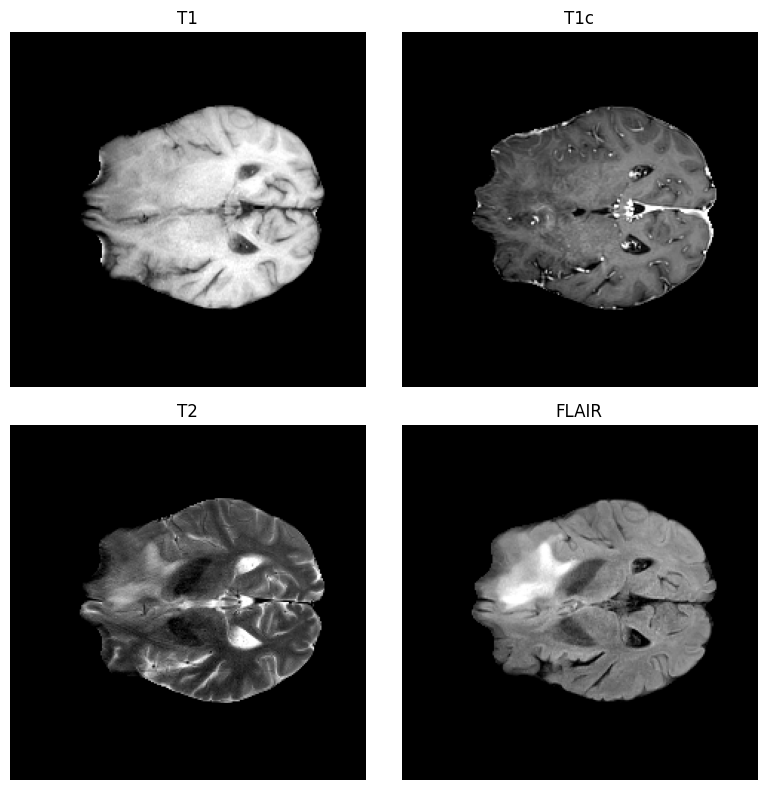

In [16]:
import matplotlib.pyplot as plt
import random

def show_sample_from_sequence(seq, sample_index=None):
    # pick a random sample from the generator if index not given
    if sample_index is None:
        batch_idx = random.randint(0, len(seq) - 1)
        x_batch, y_batch = seq[batch_idx]
        i = random.randint(0, x_batch.shape[0] - 1)
    else:
        # map a global index to batch + offset
        batch_idx = sample_index // seq.batch_size
        i = sample_index % seq.batch_size
        x_batch, y_batch = seq[batch_idx]

    x = x_batch[i]      # (240,240,4)
    y = y_batch[i]      # (3,) one-hot

    print("Sample shape:", x.shape, "Label (one-hot):", y)

    # plot each modality separately
    titles = ["T1", "T1c", "T2", "FLAIR"]
    plt.figure(figsize=(8, 8))
    for c in range(4):
        plt.subplot(2, 2, c+1)
        plt.imshow(x[:, :, c], cmap="gray")
        plt.title(titles[c])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# Show one random training slice (all 4 channels)
show_sample_from_sequence(train_gen)


In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

label_to_name = {lbl: CLASS_ROOTS[lbl][0] for lbl in CLASS_ROOTS.keys()}  # 0->GLI,1->METS,2->OTHER

def build_case_modality_df(case_dict, include_planned=False):
    rows = []
    for case_key, entry in case_dict.items():
        lbl = entry["class_label"]
        cname = entry["class_name"]
        for mod in MODALITIES:
            raw_n = len(entry["modalities"].get(mod, []))
            planned_n = None
            if include_planned:
                planned_n = len(entry["slice_plan"][mod])
            rows.append({
                "case_key": case_key,
                "class_label": lbl,
                "class_name": cname,
                "modality": mod,
                "raw_slices": raw_n,
                "planned_slices": planned_n,
            })
    return pd.DataFrame(rows)

df_raw = build_case_modality_df(case_index, include_planned=False)                 # before QC
df_clean = build_case_modality_df(clean_case_index, include_planned=True)         # after QC (planned exists)

# Dropped cases per class
dropped_by_class = []
for cid in dropped_cases:
    entry = case_index[cid]
    dropped_by_class.append(entry["class_name"])
dropped_counts = pd.Series(dropped_by_class).value_counts().reindex(["GLI","METS","OTHER"], fill_value=0)
dropped_counts

GLI       8
METS     33
OTHER    26
Name: count, dtype: int64

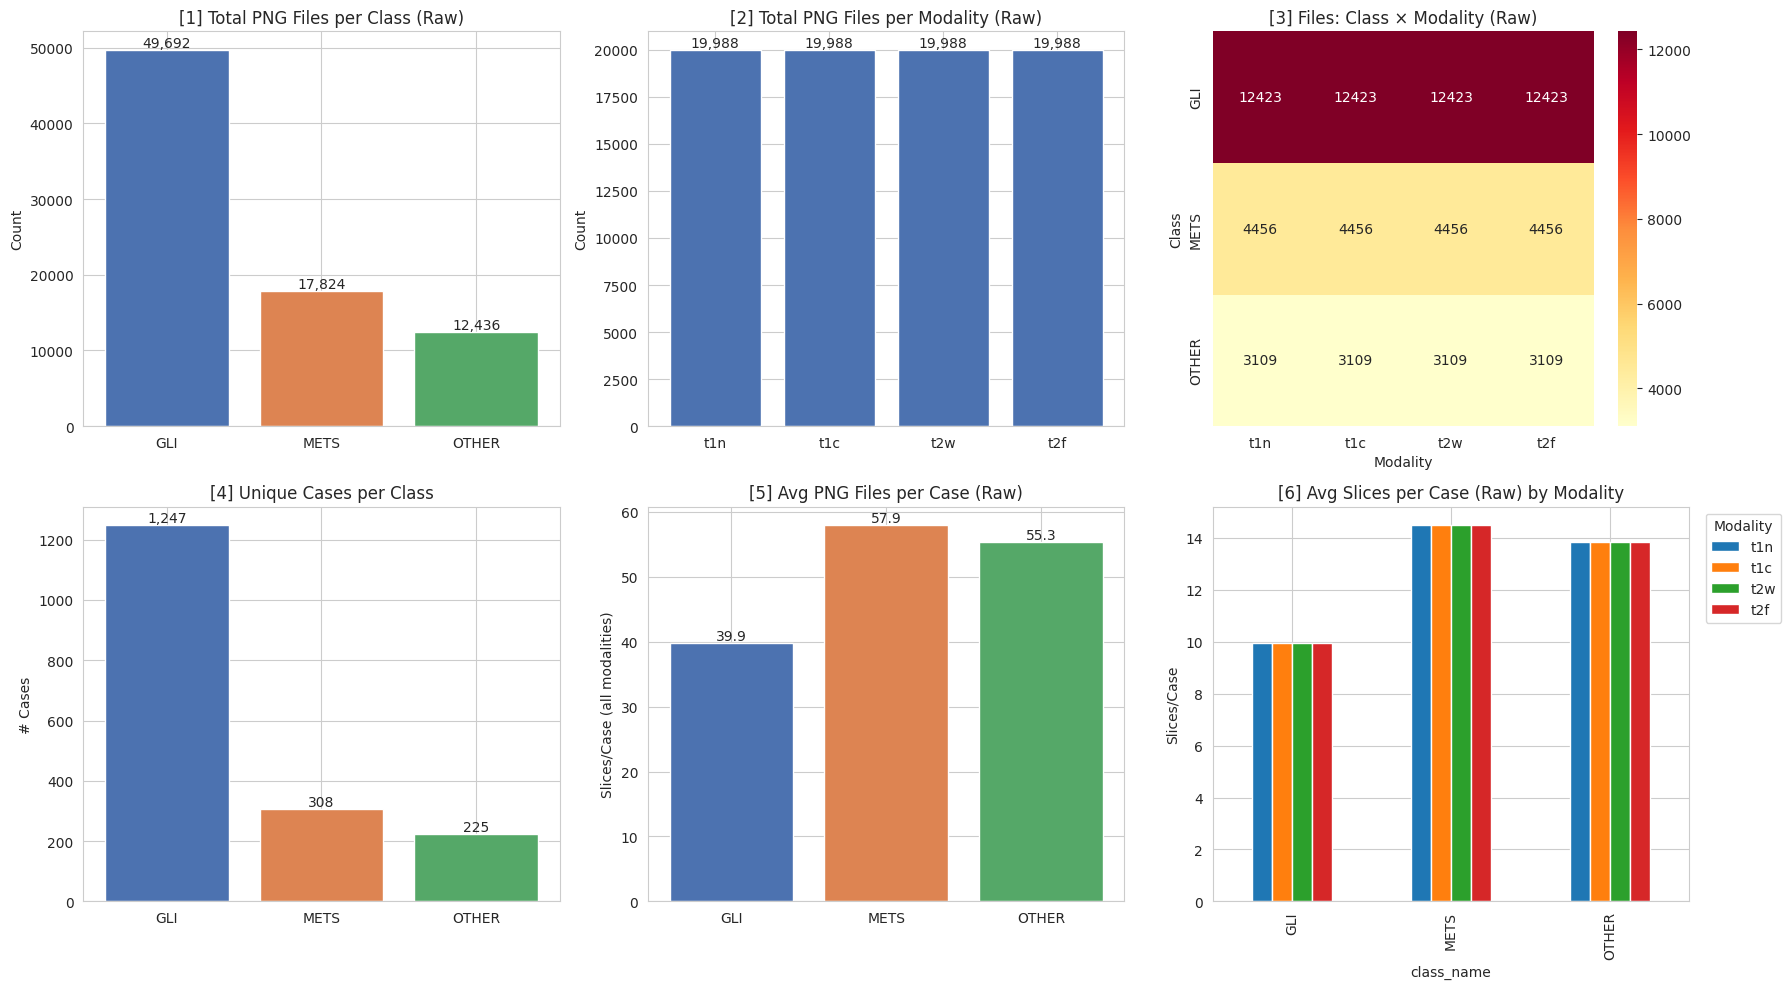

In [18]:
def plot_dataset_dashboard(df_raw):
    # Total PNGs per class (sum over modalities)
    total_png_by_class = df_raw.groupby("class_name")["raw_slices"].sum().reindex(["GLI","METS","OTHER"])

    # Total PNGs per modality (sum over classes)
    total_png_by_mod = df_raw.groupby("modality")["raw_slices"].sum().reindex(MODALITIES)

    # Heatmap class x modality
    heat = (df_raw.pivot_table(index="class_name", columns="modality", values="raw_slices", aggfunc="sum")
                 .reindex(index=["GLI","METS","OTHER"], columns=MODALITIES))

    # Unique cases per class
    cases_per_class = df_raw[["case_key","class_name"]].drop_duplicates().groupby("class_name").size().reindex(["GLI","METS","OTHER"])

    # Avg PNG per case (total over modalities / cases)
    avg_png_per_case = (total_png_by_class / cases_per_class).round(2)

    # Avg slices per case by modality
    avg_slices_case_mod = (df_raw.groupby(["class_name","modality"])["raw_slices"].mean()
                           .unstack("modality").reindex(index=["GLI","METS","OTHER"], columns=MODALITIES).round(2))

    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(2, 3)

    # [1] Total PNG files per dataset/class
    ax1 = fig.add_subplot(gs[0,0])
    bars = ax1.bar(total_png_by_class.index, total_png_by_class.values, color=["#4C72B0","#DD8452","#55A868"])
    ax1.set_title("[1] Total PNG Files per Class (Raw)")
    ax1.set_ylabel("Count")
    for b in bars:
        ax1.text(b.get_x()+b.get_width()/2, b.get_height(), f"{int(b.get_height()):,}", ha="center", va="bottom")

    # [2] Total PNG files per modality
    ax2 = fig.add_subplot(gs[0,1])
    bars = ax2.bar(total_png_by_mod.index, total_png_by_mod.values, color="#4C72B0")
    ax2.set_title("[2] Total PNG Files per Modality (Raw)")
    ax2.set_ylabel("Count")
    for b in bars:
        ax2.text(b.get_x()+b.get_width()/2, b.get_height(), f"{int(b.get_height()):,}", ha="center", va="bottom")

    # [3] Heatmap class x modality
    ax3 = fig.add_subplot(gs[0,2])
    sns.heatmap(heat, annot=True, fmt=".0f", cmap="YlOrRd", cbar=True, ax=ax3)
    ax3.set_title("[3] Files: Class × Modality (Raw)")
    ax3.set_xlabel("Modality")
    ax3.set_ylabel("Class")

    # [4] Unique cases per class
    ax4 = fig.add_subplot(gs[1,0])
    bars = ax4.bar(cases_per_class.index, cases_per_class.values, color=["#4C72B0","#DD8452","#55A868"])
    ax4.set_title("[4] Unique Cases per Class")
    ax4.set_ylabel("# Cases")
    for b in bars:
        ax4.text(b.get_x()+b.get_width()/2, b.get_height(), f"{int(b.get_height()):,}", ha="center", va="bottom")

    # [5] Avg PNG files per case
    ax5 = fig.add_subplot(gs[1,1])
    bars = ax5.bar(avg_png_per_case.index, avg_png_per_case.values, color=["#4C72B0","#DD8452","#55A868"])
    ax5.set_title("[5] Avg PNG Files per Case (Raw)")
    ax5.set_ylabel("Slices/Case (all modalities)")
    for b in bars:
        ax5.text(b.get_x()+b.get_width()/2, b.get_height(), f"{b.get_height():.1f}", ha="center", va="bottom")

    # [6] Avg slices per case by modality (grouped bars)
    ax6 = fig.add_subplot(gs[1,2])
    avg_slices_case_mod.plot(kind="bar", ax=ax6)
    ax6.set_title("[6] Avg Slices per Case (Raw) by Modality")
    ax6.set_ylabel("Slices/Case")
    ax6.legend(title="Modality", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

plot_dataset_dashboard(df_raw)

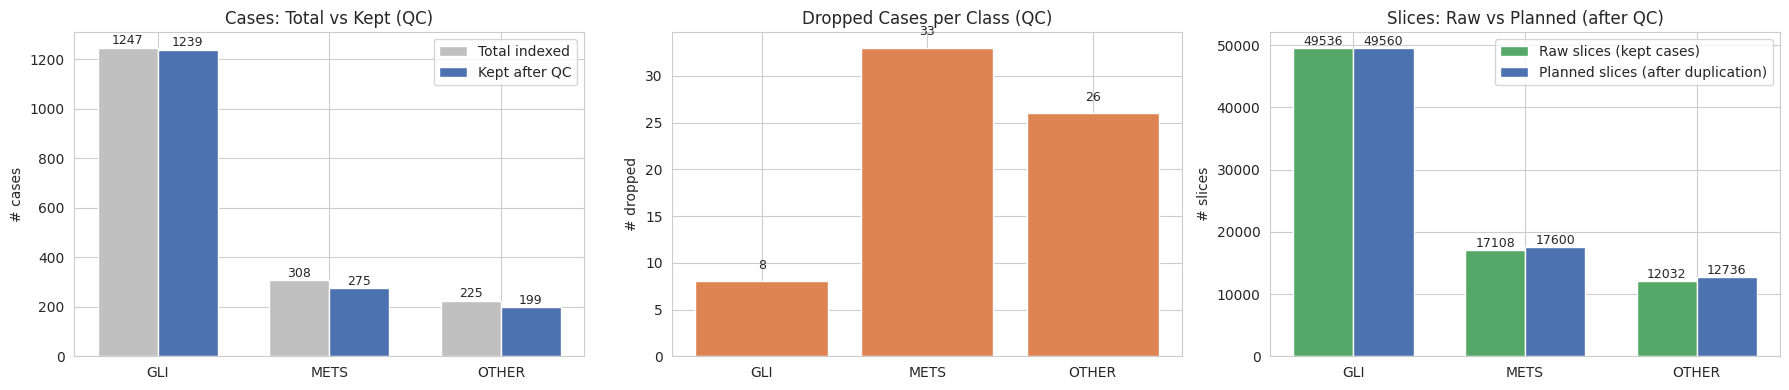

In [32]:
def plot_qc_and_planned(df_raw, df_clean, dropped_counts):
    import numpy as np
    import matplotlib.pyplot as plt

    def annotate_bars(ax, bars, offset=0):
        for b in bars:
            h = b.get_height()
            ax.text(
                b.get_x() + b.get_width() / 2,
                h + offset,
                f"{int(h)}",
                ha="center",
                va="bottom",
                fontsize=9
            )

    # kept cases per class
    kept_cases = (
        df_clean[["case_key","class_name"]]
        .drop_duplicates()
        .groupby("class_name")
        .size()
        .reindex(["GLI","METS","OTHER"], fill_value=0)
    )

    total_cases = (
        df_raw[["case_key","class_name"]]
        .drop_duplicates()
        .groupby("class_name")
        .size()
        .reindex(["GLI","METS","OTHER"], fill_value=0)
    )

    # planned slice totals per class
    planned_total_by_class = (
        df_clean.groupby("class_name")["planned_slices"]
        .sum()
        .reindex(["GLI","METS","OTHER"])
    )

    # raw slice totals (kept cases)
    raw_total_kept_by_class = (
        df_clean.groupby("class_name")["raw_slices"]
        .sum()
        .reindex(["GLI","METS","OTHER"])
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    names = ["GLI","METS","OTHER"]
    x = np.arange(3)

    # --- Plot 1: Total vs Kept cases (SIDE-BY-SIDE) ---
    ax = axes[0]
    w = 0.35
    
    bars_total = ax.bar(
        x - w/2,
        total_cases.values,
        width=w,
        label="Total indexed",
        color="#C0C0C0"
    )
    
    bars_kept = ax.bar(
        x + w/2,
        kept_cases.values,
        width=w,
        label="Kept after QC",
        color="#4C72B0"
    )
    
    ax.set_xticks(x)
    ax.set_xticklabels(names)
    ax.set_title("Cases: Total vs Kept (QC)")
    ax.set_ylabel("# cases")
    ax.legend()
    
    annotate_bars(ax, bars_total, offset=2)
    annotate_bars(ax, bars_kept, offset=2)


    # --- Plot 2: Dropped cases ---
    ax = axes[1]
    bars_dropped = ax.bar(dropped_counts.index, dropped_counts.values, color="#DD8452")
    ax.set_title("Dropped Cases per Class (QC)")
    ax.set_ylabel("# dropped")

    annotate_bars(ax, bars_dropped, offset=1)

    # --- Plot 3: Raw vs Planned slices ---
    ax = axes[2]
    w = 0.35
    bars_raw = ax.bar(
        x - w/2,
        raw_total_kept_by_class.values,
        width=w,
        label="Raw slices (kept cases)",
        color="#55A868"
    )
    bars_planned = ax.bar(
        x + w/2,
        planned_total_by_class.values,
        width=w,
        label="Planned slices (after duplication)",
        color="#4C72B0"
    )

    ax.set_xticks(x)
    ax.set_xticklabels(names)
    ax.set_title("Slices: Raw vs Planned (after QC)")
    ax.set_ylabel("# slices")
    ax.legend()

    annotate_bars(ax, bars_raw, offset=10)
    annotate_bars(ax, bars_planned, offset=10)

    plt.tight_layout()
    plt.show()
plot_qc_and_planned(df_raw, df_clean, dropped_counts)

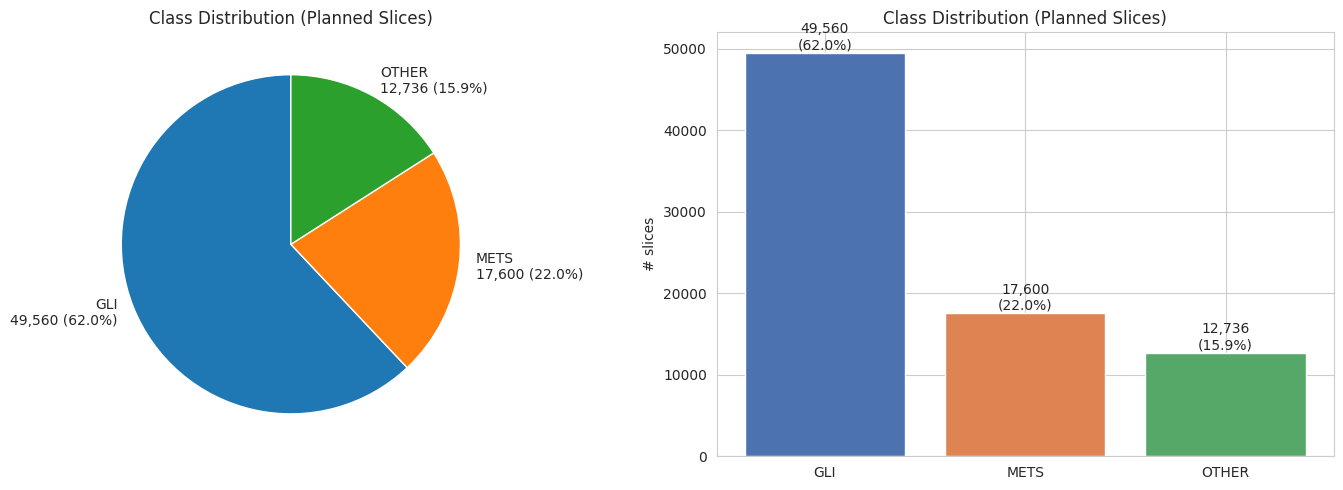

In [20]:
def plot_class_distribution_planned(df_clean):
    planned_by_class = df_clean.groupby("class_name")["planned_slices"].sum().reindex(["GLI","METS","OTHER"])
    total = planned_by_class.sum()
    pct = (planned_by_class / total * 100).round(1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Pie
    axes[0].pie(planned_by_class.values,
                labels=[f"{k}\n{v:,} ({pct[k]}%)" for k,v in planned_by_class.items()],
                startangle=90)
    axes[0].set_title("Class Distribution (Planned Slices)")

    # Bar
    bars = axes[1].bar(planned_by_class.index, planned_by_class.values, color=["#4C72B0","#DD8452","#55A868"])
    axes[1].set_title("Class Distribution (Planned Slices)")
    axes[1].set_ylabel("# slices")
    for b, name in zip(bars, planned_by_class.index):
        axes[1].text(b.get_x()+b.get_width()/2, b.get_height(),
                     f"{int(b.get_height()):,}\n({pct[name]}%)",
                     ha="center", va="bottom")

    plt.tight_layout()
    plt.show()

plot_class_distribution_planned(df_clean)

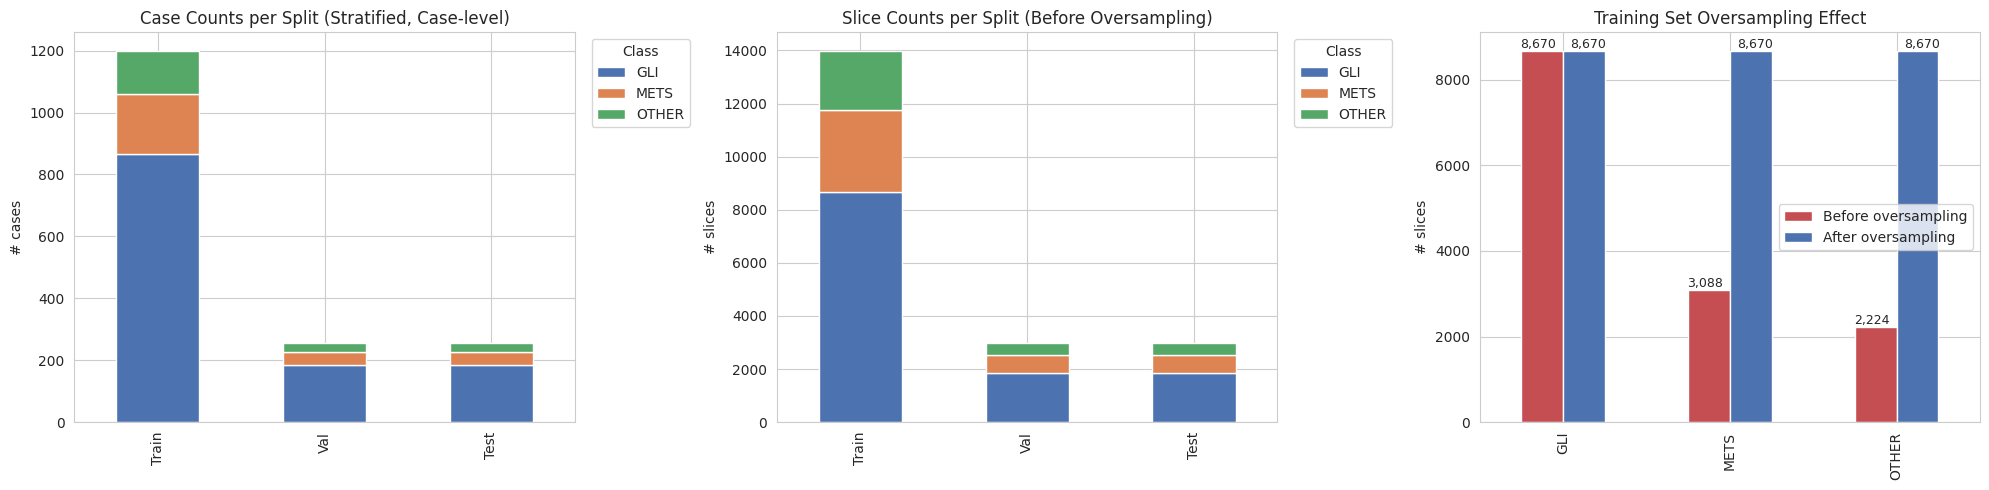

In [21]:
from collections import Counter

def plot_splits_and_oversampling(clean_case_index, train_cases, val_cases, test_cases,
                                 train_slices, val_slices, test_slices, balanced_train_slices):
    def cases_per_class(case_set):
        c = Counter()
        for cid in case_set:
            c[clean_case_index[cid]["class_name"]] += 1
        return pd.Series(c).reindex(["GLI","METS","OTHER"], fill_value=0)

    def slices_per_class(slice_list):
        c = Counter()
        for _,_,lbl in slice_list:
            c[label_to_name[lbl]] += 1
        return pd.Series(c).reindex(["GLI","METS","OTHER"], fill_value=0)

    # Cases
    cases_df = pd.DataFrame({
        "Train": cases_per_class(train_cases),
        "Val":   cases_per_class(val_cases),
        "Test":  cases_per_class(test_cases),
    })

    # Slices (before OS)
    slices_df = pd.DataFrame({
        "Train": slices_per_class(train_slices),
        "Val":   slices_per_class(val_slices),
        "Test":  slices_per_class(test_slices),
    })

    # Oversampling: before vs after in train
    train_before = slices_per_class(train_slices)
    train_after  = slices_per_class(balanced_train_slices)
    os_df = pd.DataFrame({"Before oversampling": train_before, "After oversampling": train_after})

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # Cases per split (stacked)
    cases_df.T.plot(kind="bar", stacked=True, ax=axes[0], color=["#4C72B0","#DD8452","#55A868"])
    axes[0].set_title("Case Counts per Split (Stratified, Case-level)")
    axes[0].set_ylabel("# cases")
    axes[0].legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")

    # Slices per split (stacked, before OS)
    slices_df.T.plot(kind="bar", stacked=True, ax=axes[1], color=["#4C72B0","#DD8452","#55A868"])
    axes[1].set_title("Slice Counts per Split (Before Oversampling)")
    axes[1].set_ylabel("# slices")
    axes[1].legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")

    # Oversampling effect
    os_df.plot(kind="bar", ax=axes[2], color=["#C44E52","#4C72B0"])
    axes[2].set_title("Training Set Oversampling Effect")
    axes[2].set_ylabel("# slices")
    for i, cls in enumerate(os_df.index):
        axes[2].text(i-0.15, os_df.iloc[i,0], f"{int(os_df.iloc[i,0]):,}", ha="center", va="bottom", fontsize=9)
        axes[2].text(i+0.15, os_df.iloc[i,1], f"{int(os_df.iloc[i,1]):,}", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.show()

plot_splits_and_oversampling(clean_case_index, train_cases, val_cases, test_cases,
                            train_slices, val_slices, test_slices, balanced_train_slices)

Class: GLI | one-hot: [1. 0. 0.]


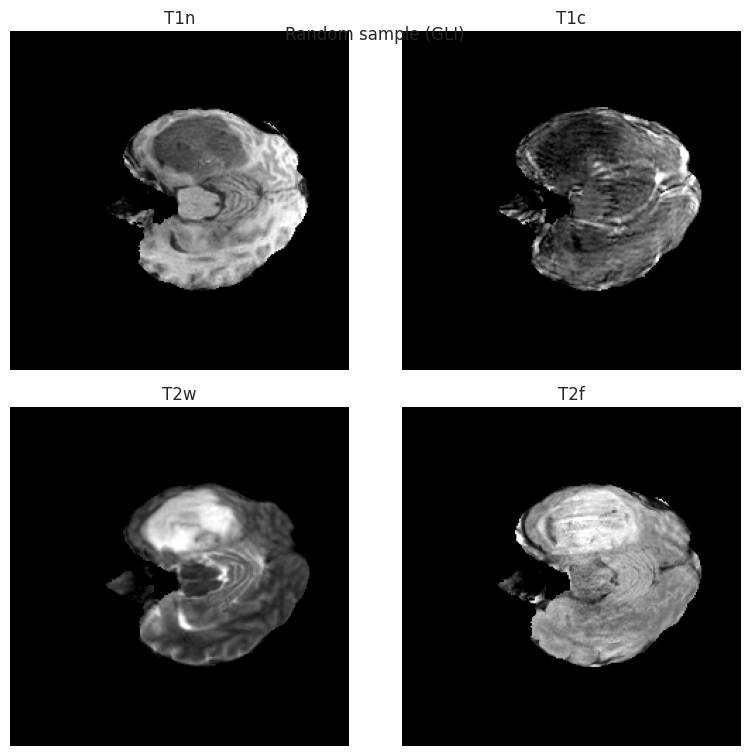

Class: METS | one-hot: [0. 1. 0.]


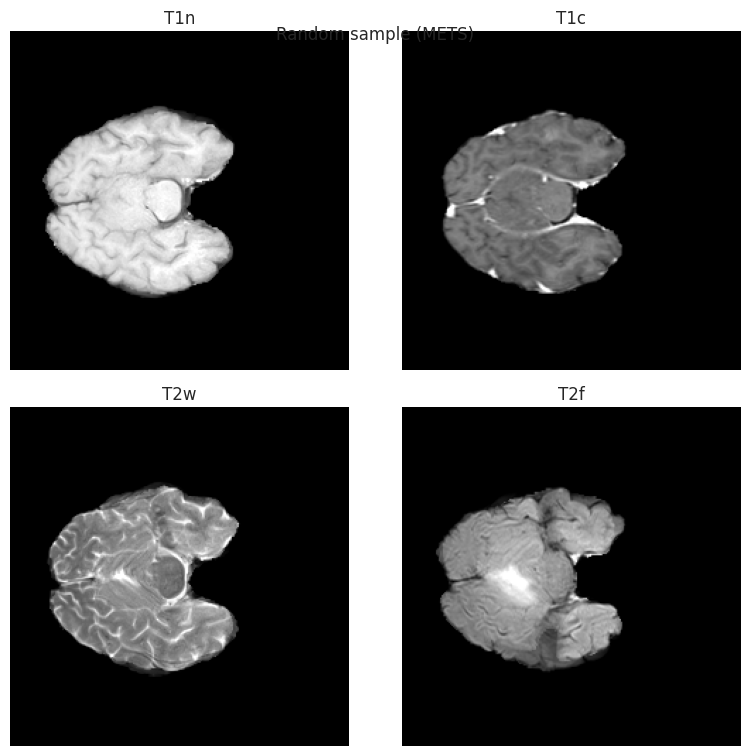

Class: OTHER | one-hot: [0. 0. 1.]


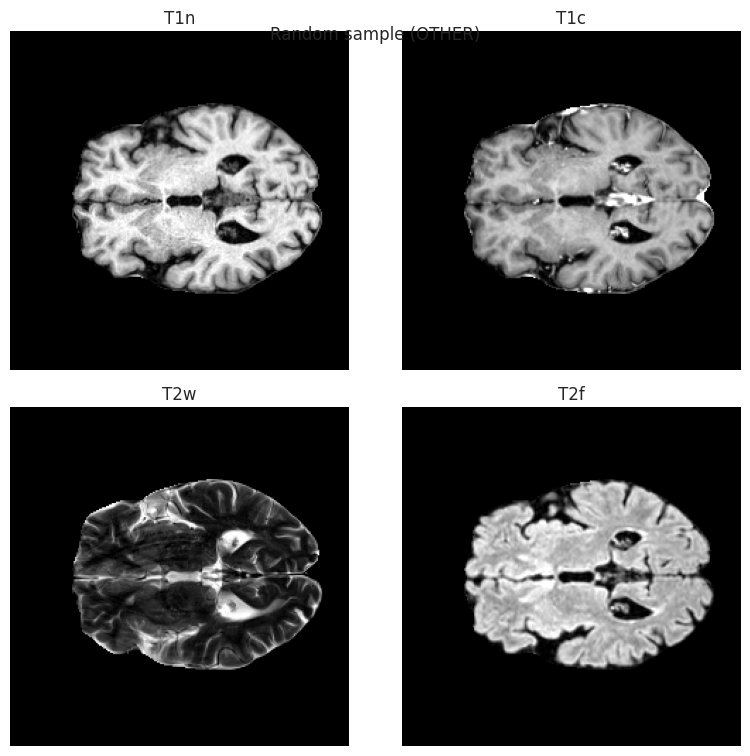

In [18]:
import random
import matplotlib.pyplot as plt

def show_one_per_class(seq, class_names=("GLI","METS","OTHER"), tries=500):
    # brute-force search random batches until we find each class
    found = {c: None for c in class_names}

    for _ in range(tries):
        b = random.randint(0, len(seq)-1)
        x_batch, y_batch = seq[b]
        y_lbl = np.argmax(y_batch, axis=1)
        for i in range(x_batch.shape[0]):
            cname = label_to_name[int(y_lbl[i])]
            if cname in found and found[cname] is None:
                found[cname] = (x_batch[i], y_batch[i])
        if all(found[c] is not None for c in class_names):
            break

    titles = ["T1n", "T1c", "T2w", "T2f"]
    for cname in class_names:
        if found[cname] is None:
            print(f"Could not find class {cname} in {tries} tries.")
            continue
        x, y = found[cname]
        print(f"Class: {cname} | one-hot: {y}")

        plt.figure(figsize=(8,8))
        for c in range(4):
            plt.subplot(2,2,c+1)
            plt.imshow(x[:,:,c], cmap="gray")
            plt.title(titles[c])
            plt.axis("off")
        plt.suptitle(f"Random sample ({cname})", y=0.92)
        plt.tight_layout()
        plt.show()

show_one_per_class(train_gen)

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

CLASS_NAMES = ["GLI", "METS", "OTHER"]  # label 2 is MEN mapped to OTHER

def count_cases_per_class(case_set, case_index):
    c = Counter()
    for cid in case_set:
        c[case_index[cid]["class_name"]] += 1
    return [c.get(k, 0) for k in CLASS_NAMES]

def count_slices_per_class(samples):
    # samples = list of (case_key, local_idx, label)
    c = Counter()
    for _, _, lbl in samples:
        c[CLASS_NAMES[lbl]] += 1
    return [c.get(k, 0) for k in CLASS_NAMES]

def add_bar_labels(ax, bars, fmt="{:,}", y_offset=0.01):
    ymax = ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, h + ymax*y_offset, fmt.format(int(h)),
                ha="center", va="bottom", fontsize=10, fontweight="bold")

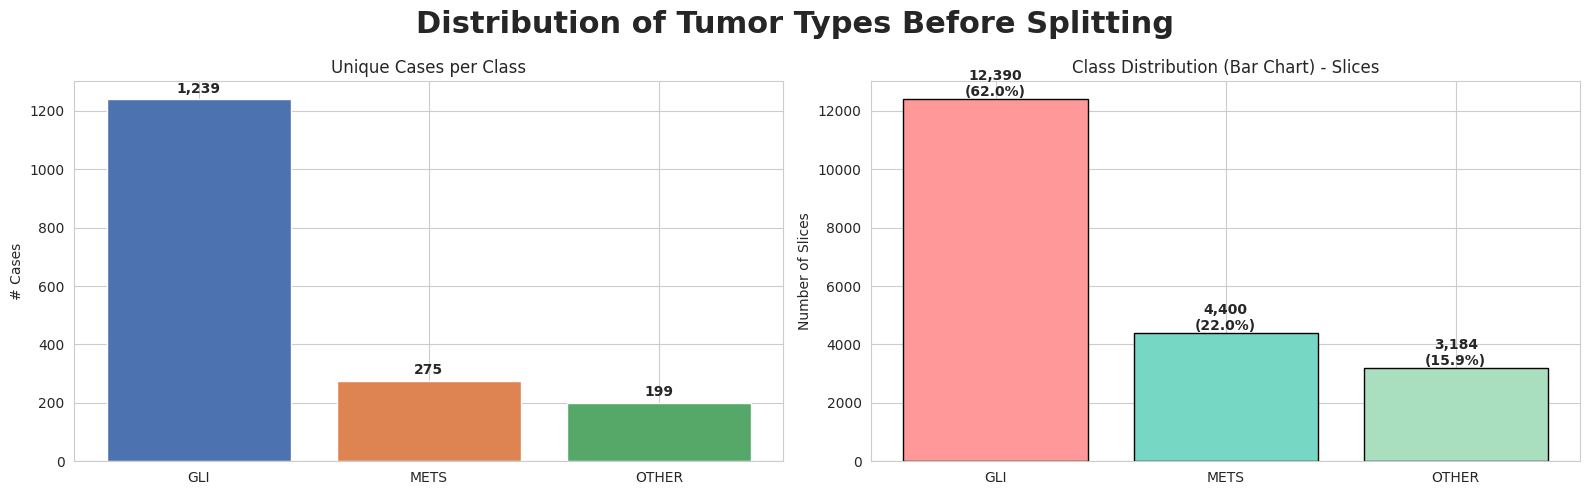

In [20]:
def plot_before_splitting(clean_case_index, slice_samples):
    # unique cases per class
    all_cases = list(clean_case_index.keys())
    case_counts = Counter([clean_case_index[c]["class_name"] for c in all_cases])
    case_vals = [case_counts.get(k, 0) for k in CLASS_NAMES]

    # slices per class (planned)
    slice_vals = count_slices_per_class(slice_samples)
    total_slices = sum(slice_vals)
    pct = [v/total_slices*100 for v in slice_vals]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle("Distribution of Tumor Types Before Splitting", fontsize=22, fontweight="bold")

    # Left: cases
    ax = axes[0]
    bars = ax.bar(CLASS_NAMES, case_vals, color=["#4C72B0", "#DD8452", "#55A868"])
    ax.set_title("Unique Cases per Class")
    ax.set_ylabel("# Cases")
    add_bar_labels(ax, bars)

    # Right: slices
    ax = axes[1]
    bars = ax.bar(CLASS_NAMES, slice_vals, color=["#FF9999", "#76D7C4", "#A9DFBF"], edgecolor="black")
    ax.set_title("Class Distribution (Bar Chart) - Slices")
    ax.set_ylabel("Number of Slices")
    for b, p in zip(bars, pct):
        h = b.get_height()
        ax.text(b.get_x()+b.get_width()/2, h, f"{int(h):,}\n({p:.1f}%)",
                ha="center", va="bottom", fontsize=10, fontweight="bold")

    plt.tight_layout()
    plt.show()

plot_before_splitting(clean_case_index, slice_samples)

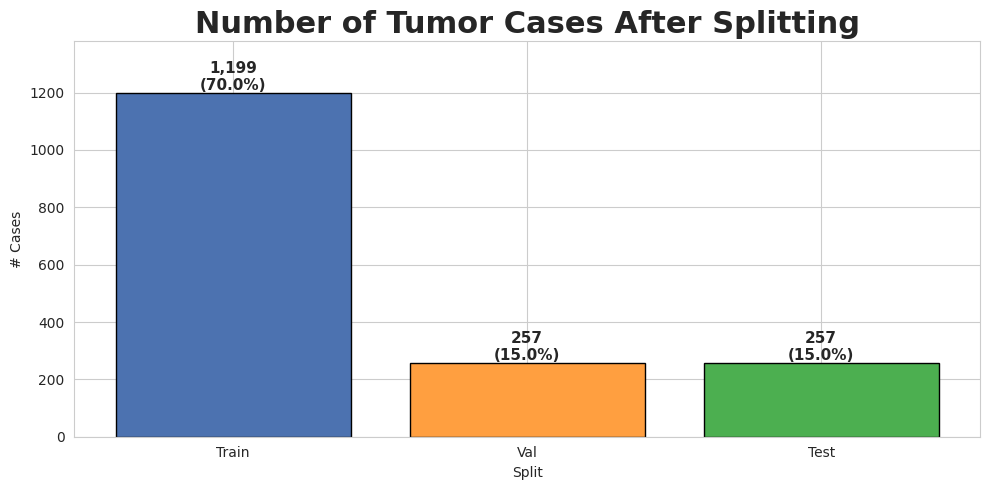

In [35]:
def plot_cases_after_splitting(train_cases, val_cases, test_cases):
    split_names = ["Train", "Val", "Test"]
    split_counts = [len(train_cases), len(val_cases), len(test_cases)]
    total = sum(split_counts)
    split_pct = [c/total*100 for c in split_counts]

    plt.figure(figsize=(10, 5))
    plt.title("Number of Tumor Cases After Splitting", fontsize=22, fontweight="bold")
    bars = plt.bar(split_names, split_counts, color=["#4C72B0", "#FF9F40", "#4CAF50"], edgecolor="black")
    plt.ylabel("# Cases")
    plt.xlabel("Split")

    ymax = max(split_counts) if max(split_counts) > 0 else 1
    plt.ylim(0, ymax * 1.15)

    for b, p in zip(bars, split_pct):
        h = b.get_height()
        plt.text(b.get_x()+b.get_width()/2, h, f"{int(h):,}\n({p:.1f}%)",
                 ha="center", va="bottom", fontsize=11, fontweight="bold")

    plt.tight_layout()
    plt.show()

plot_cases_after_splitting(train_cases, val_cases, test_cases)

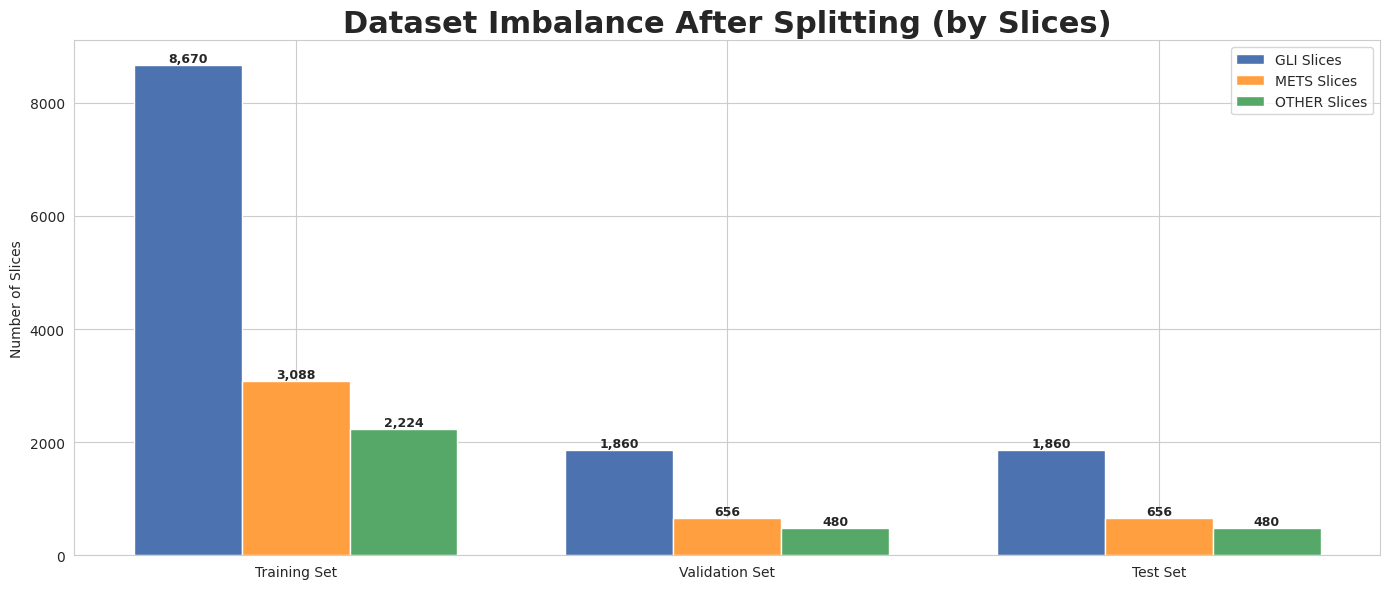

In [36]:
def plot_slice_imbalance_after_splitting(train_slices, val_slices, test_slices):
    splits = ["Training Set", "Validation Set", "Test Set"]
    data = np.array([
        count_slices_per_class(train_slices),
        count_slices_per_class(val_slices),
        count_slices_per_class(test_slices),
    ])  # shape: (3 splits, 3 classes)

    x = np.arange(len(splits))
    w = 0.25

    plt.figure(figsize=(14, 6))
    plt.title("Dataset Imbalance After Splitting (by Slices)", fontsize=22, fontweight="bold")
    plt.ylabel("Number of Slices")

    colors = ["#4C72B0", "#FF9F40", "#55A868"]
    for i, cls in enumerate(CLASS_NAMES):
        bars = plt.bar(x + (i-1)*w, data[:, i], width=w, label=f"{cls} Slices", color=colors[i])
        for b in bars:
            h = b.get_height()
            plt.text(b.get_x()+b.get_width()/2, h, f"{int(h):,}",
                     ha="center", va="bottom", fontsize=9, fontweight="bold")

    plt.xticks(x, splits)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_slice_imbalance_after_splitting(train_slices, val_slices, test_slices)

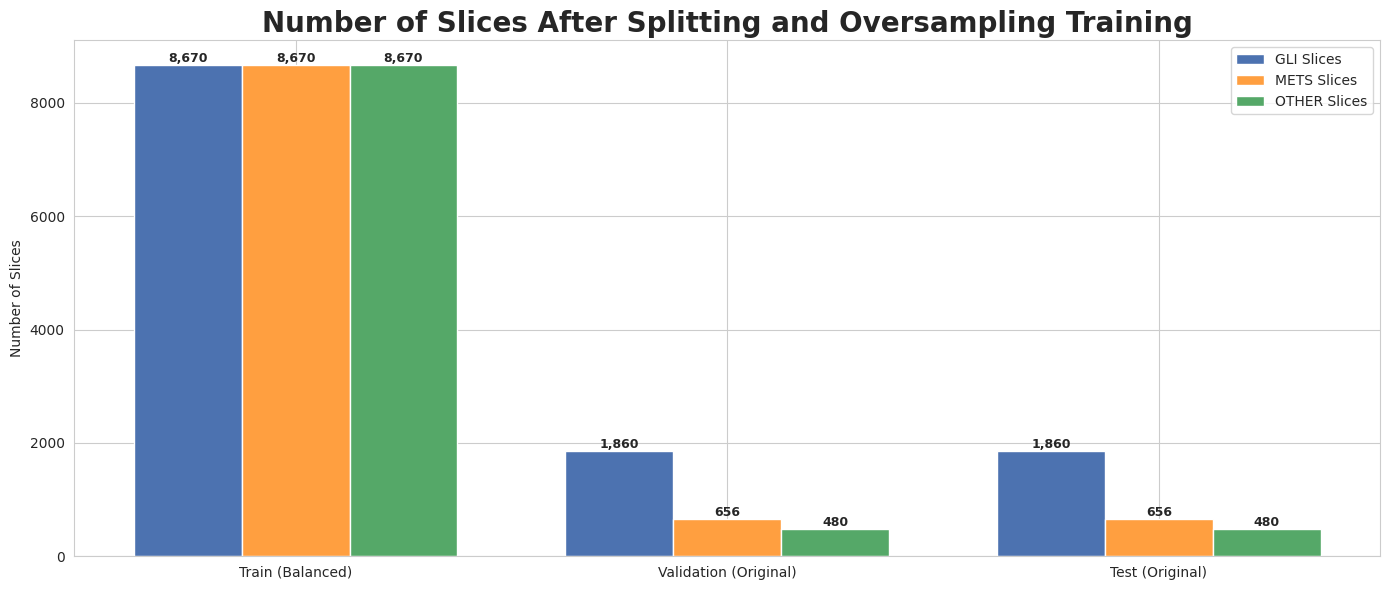

In [37]:
def plot_slices_after_oversampling(balanced_train_slices, val_slices, test_slices):
    splits = ["Train (Balanced)", "Validation (Original)", "Test (Original)"]
    data = np.array([
        count_slices_per_class(balanced_train_slices),
        count_slices_per_class(val_slices),
        count_slices_per_class(test_slices),
    ])

    x = np.arange(len(splits))
    w = 0.25

    plt.figure(figsize=(14, 6))
    plt.title("Number of Slices After Splitting and Oversampling Training", fontsize=20, fontweight="bold")
    plt.ylabel("Number of Slices")

    colors = ["#4C72B0", "#FF9F40", "#55A868"]
    for i, cls in enumerate(CLASS_NAMES):
        bars = plt.bar(x + (i-1)*w, data[:, i], width=w, label=f"{cls} Slices", color=colors[i])
        for b in bars:
            h = b.get_height()
            plt.text(b.get_x()+b.get_width()/2, h, f"{int(h):,}",
                     ha="center", va="bottom", fontsize=9, fontweight="bold")

    plt.xticks(x, splits)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_slices_after_oversampling(balanced_train_slices, val_slices, test_slices)

# Inception Model 

In [15]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input

IMG_HEIGHT = 240
IMG_WIDTH  = 240
NUM_CLASSES = 3

def build_inceptionv3_4ch_to_3class(input_shape=(IMG_HEIGHT, IMG_WIDTH, 4),
                                     train_base=False,
                                     dropout1=0.4,
                                     dropout2=0.3):
    """
    InceptionV3 adapted for 4-channel MRI input (T1n, T1c, T2w, T2f)
    with 3-class output (GLI, METS, OTHER).
    
    Args:
        input_shape: (240, 240, 4)
        train_base: If False, freeze InceptionV3 backbone
        dropout1: First dropout rate
        dropout2: Second dropout rate
    
    Returns:
        Keras Model
    """
    
    inp = layers.Input(shape=input_shape, name="input_4ch")
    
    # 4→3 channel adapter (learned 1×1 convolution)
    x = layers.Conv2D(3, (1, 1), padding="same", name="adapter_4to3")(inp)
    
    # InceptionV3 preprocessing expects [0, 255] then scales to [-1, 1]
    x = layers.Lambda(lambda t: t * 255.0, name="to_255")(x)
    x = layers.Lambda(preprocess_input, name="inception_preprocess")(x)
    
    # Load InceptionV3 pretrained on ImageNet
    base = InceptionV3(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    )
    base.trainable = train_base  # Frozen for initial training
    
    feat = base(x)
    
    # Classification head
    h = layers.GlobalAveragePooling2D(name="gap")(feat)
    h = layers.Dropout(dropout1, name="drop1")(h)
    h = layers.Dense(256, activation="relu", name="fc1")(h)
    h = layers.Dropout(dropout2, name="drop2")(h)
    out = layers.Dense(NUM_CLASSES, activation="softmax", name="pred")(h)
    
    model = Model(inputs=inp, outputs=out, name="InceptionV3_4ch_3class")
    return model

# Build the model (backbone frozen)
model_inception = build_inceptionv3_4ch_to_3class(train_base=False)

print("✅ InceptionV3 model created successfully!")

I0000 00:00:1770122211.346546      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
✅ InceptionV3 model created successfully!


# compile the Model

In [16]:
multi_auc = tf.keras.metrics.AUC(
    multi_label=True, 
    num_labels=NUM_CLASSES, 
    name="auc"
)

model_inception.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy", multi_auc]
)

print("✅ Model compiled with Adam (lr=1e-4), categorical_crossentropy, and AUC metric")

✅ Model compiled with Adam (lr=1e-4), categorical_crossentropy, and AUC metric


In [17]:
model_inception.summary()

Model: "InceptionV3_4ch_3class"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_4ch (InputLayer)          │ (None, 240, 240, 4)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ adapter_4to3 (Conv2D)           │ (None, 240, 240, 3)    │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ to_255 (Lambda)                 │ (None, 240, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_preprocess (Lambda)   │ (None, 240, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 6, 6, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pred (Dense)                    │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,328,114 (85.17 MB)

 Trainable params: 525,330 (2.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [18]:
# Test forward pass
xb, yb = train_gen[0]
print("Input batch shape:", xb.shape, "| Range:", xb.min(), "-", xb.max())
print("Label batch shape:", yb.shape, "| Classes in batch:", sorted(set(yb.argmax(axis=1))))

pred = model_inception(xb[:2])
print("Prediction shape:", pred.shape)
print("Prediction row sums (should be ~1.0):", tf.reduce_sum(pred, axis=1).numpy())

Input batch shape: (32, 240, 240, 4) | Range: 0.0 - 1.0
Label batch shape: (32, 3) | Classes in batch: [np.int64(0), np.int64(1), np.int64(2)]


I0000 00:00:1770122262.170102      55 cuda_dnn.cc:529] Loaded cuDNN version 91002


Prediction shape: (2, 3)
Prediction row sums (should be ~1.0): [1. 1.]


# Add the Callbacks

In [19]:
EPOCHS_STAGE0 = 30  # Initial training epochs (you can adjust)

ckpt_path_stage0 = "inceptionv3_3class_stage0_best.keras"

callbacks_stage0 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        ckpt_path_stage0,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]

print("✅ Callbacks configured:")
print("  - EarlyStopping: patience=6 on val_auc")
print("  - ReduceLROnPlateau: factor=0.5, patience=3")
print("  - ModelCheckpoint: saves best val_auc model")

✅ Callbacks configured:
  - EarlyStopping: patience=6 on val_auc
  - ReduceLROnPlateau: factor=0.5, patience=3
  - ModelCheckpoint: saves best val_auc model


In [20]:
print("🚀 Starting Stage 0 training (frozen InceptionV3 backbone)...")
print(f"   Training only: adapter (4→3) + classification head (~132K params)")
print(f"   Epochs: {EPOCHS_STAGE0}")
print(f"   Learning rate: 1e-4\n")

history_stage0 = model_inception.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_STAGE0,
    callbacks=callbacks_stage0,
    verbose=1
)

print("\n✅ Stage 0 training complete!")

🚀 Starting Stage 0 training (frozen InceptionV3 backbone)...
   Training only: adapter (4→3) + classification head (~132K params)
   Epochs: 30
   Learning rate: 1e-4

Epoch 1/30


I0000 00:00:1770122284.490693     128 service.cc:152] XLA service 0x784d44002970 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770122284.490731     128 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


  1/813 ━━━━━━━━━━━━━━━━━━━━ 5:02:04 22s/step - accuracy: 0.4062 - auc: 0.5249 - loss: 1.4001

I0000 00:00:1770122299.131476     128 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


813/813 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.5716 - auc: 0.7542 - loss: 0.9235
Epoch 1: val_auc improved from -inf to 0.83100, saving model to inceptionv3_3class_stage0_best.keras
813/813 ━━━━━━━━━━━━━━━━━━━━ 262s 295ms/step - accuracy: 0.5716 - auc: 0.7543 - loss: 0.9234 - val_accuracy: 0.6822 - val_auc: 0.8310 - val_loss: 0.6960 - learning_rate: 1.0000e-04
Epoch 2/30
813/813 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.7089 - auc: 0.8742 - loss: 0.6669
Epoch 2: val_auc improved from 0.83100 to 0.84778, saving model to inceptionv3_3class_stage0_best.keras
813/813 ━━━━━━━━━━━━━━━━━━━━ 176s 216ms/step - accuracy: 0.7089 - auc: 0.8742 - loss: 0.6669 - val_accuracy: 0.6916 - val_auc: 0.8478 - val_loss: 0.6868 - learning_rate: 1.0000e-04
Epoch 3/30
813/813 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.7483 - auc: 0.9010 - loss: 0.5920
Epoch 3: val_auc improved from 0.84778 to 0.85696, saving model to inceptionv3_3class_stage0_best.keras
813/813 ━━━━━━━━━━━━━━━━━━━━ 178s 

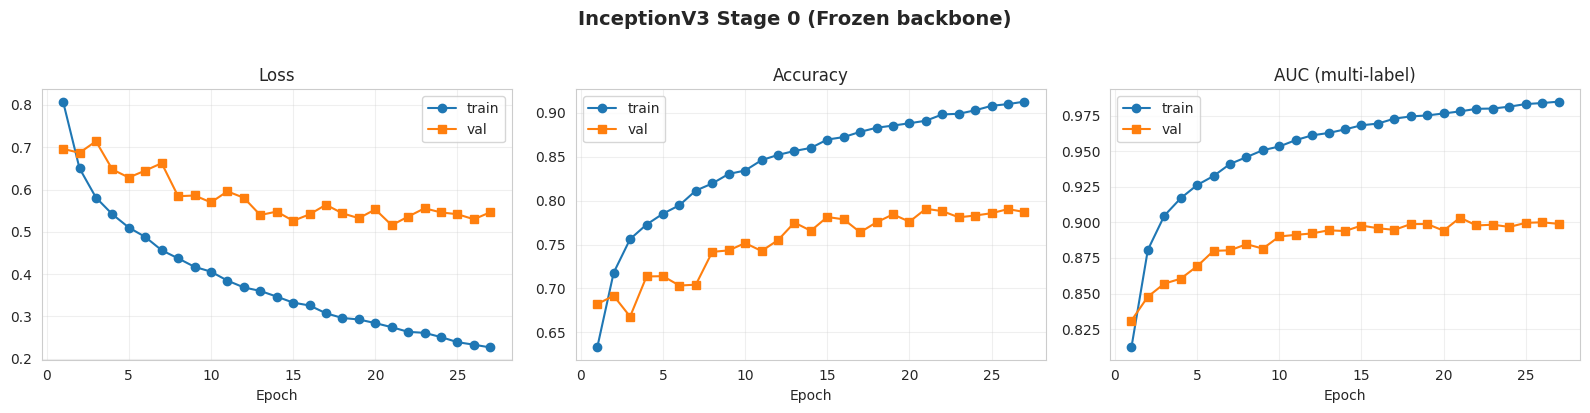

In [21]:
import matplotlib.pyplot as plt

def plot_history(hist, title="Training Curves"):
    h = hist.history
    epochs = range(1, len(h["loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    # Loss
    axes[0].plot(epochs, h["loss"], label="train", marker='o')
    axes[0].plot(epochs, h["val_loss"], label="val", marker='s')
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(epochs, h["accuracy"], label="train", marker='o')
    axes[1].plot(epochs, h["val_accuracy"], label="val", marker='s')
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # AUC
    axes[2].plot(epochs, h["auc"], label="train", marker='o')
    axes[2].plot(epochs, h["val_auc"], label="val", marker='s')
    axes[2].set_title("AUC (multi-label)")
    axes[2].set_xlabel("Epoch")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

plot_history(history_stage0, "InceptionV3 Stage 0 (Frozen backbone)")

📊 EVALUATION: STAGE 0 (Frozen InceptionV3 Backbone)
94/94 ━━━━━━━━━━━━━━━━━━━━ 84s 839ms/step

🔹 SLICE-LEVEL RESULTS (Stage 0)
Accuracy: 79.91%

              precision    recall  f1-score   support

         GLI     0.8552    0.8478    0.8515      1860
        METS     0.8169    0.8567    0.8363       656
       OTHER     0.5496    0.5312    0.5403       480

    accuracy                         0.7991      2996
   macro avg     0.7405    0.7453    0.7427      2996
weighted avg     0.7978    0.7991    0.7983      2996



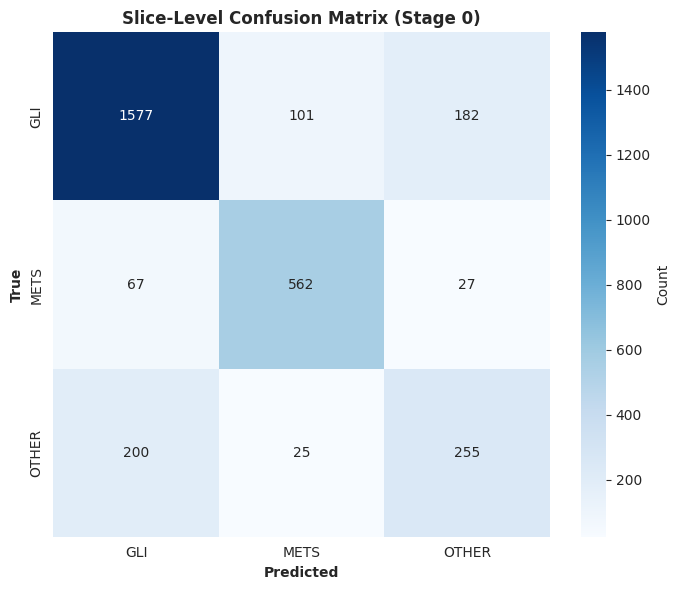

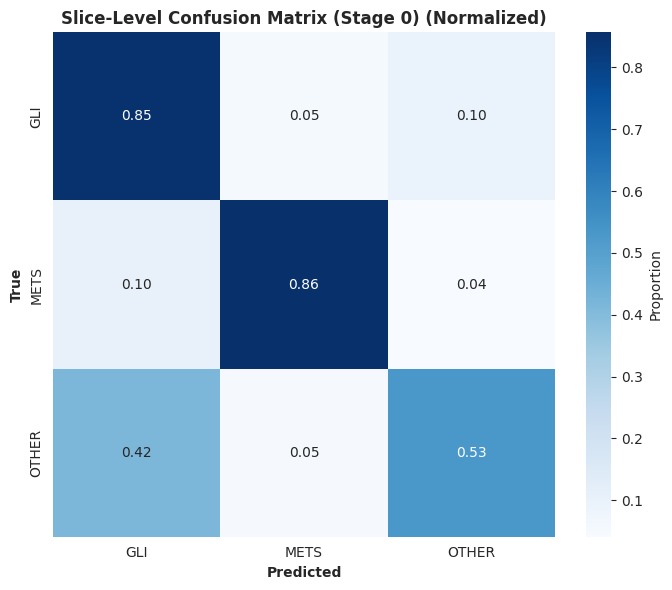


🔹 CASE-LEVEL RESULTS (Majority Voting - Stage 0)
Accuracy: 89.11%

              precision    recall  f1-score   support

         GLI     0.9119    0.9462    0.9288       186
        METS     0.8605    0.9024    0.8810        41
       OTHER     0.7619    0.5333    0.6275        30

    accuracy                         0.8911       257
   macro avg     0.8448    0.7940    0.8124       257
weighted avg     0.8862    0.8911    0.8860       257



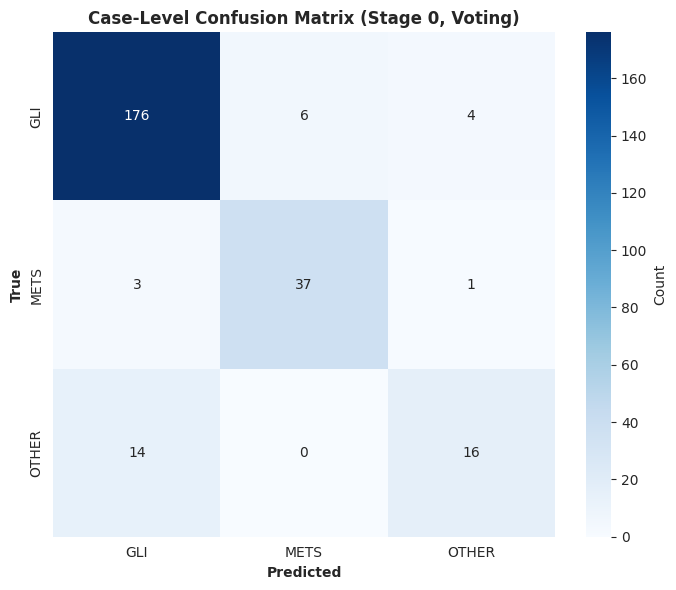

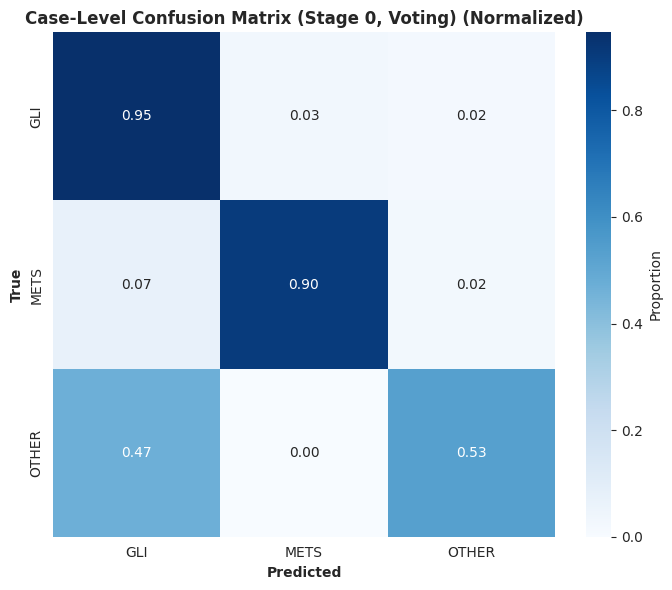

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

CLASS_NAMES = ["GLI", "METS", "OTHER"]

def plot_cm(y_true, y_pred, title, normalize=False):
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype("float") / (cm.sum(axis=1, keepdims=True) + 1e-12)

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm, annot=True, 
        fmt=".2f" if normalize else "d",
        cmap="Blues", 
        xticklabels=CLASS_NAMES, 
        yticklabels=CLASS_NAMES,
        cbar_kws={'label': 'Count' if not normalize else 'Proportion'}
    )
    plt.title(title + (" (Normalized)" if normalize else ""), fontweight="bold")
    plt.xlabel("Predicted", fontweight="bold")
    plt.ylabel("True", fontweight="bold")
    plt.tight_layout()
    plt.show()

def predict_with_metadata(model, gen):
    y_prob = model.predict(gen, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)
    case_keys = [ck for (ck, local_idx, lbl) in gen.samples]
    y_true = np.array([lbl for (ck, local_idx, lbl) in gen.samples], dtype=np.int32)
    return y_true, y_pred, y_prob, case_keys

def majority_vote(arr, n_classes=3):
    counts = np.bincount(arr, minlength=n_classes)
    top = counts.max()
    tied = np.where(counts == top)[0]
    return int(tied[0])

def case_level_vote(y_pred_slice, case_keys, clean_case_index):
    df = pd.DataFrame({"case_key": case_keys, "pred": y_pred_slice})
    y_pred_case = df.groupby("case_key")["pred"].apply(
        lambda s: majority_vote(s.values, n_classes=3)
    )
    y_true_case = y_pred_case.index.to_series().apply(
        lambda ck: clean_case_index[ck]["class_label"]
    )
    return y_true_case.values.astype(int), y_pred_case.values.astype(int)

# ----- Evaluate on test set -----
print("=" * 70)
print("📊 EVALUATION: STAGE 0 (Frozen InceptionV3 Backbone)")
print("=" * 70)

eval_gen = test_gen  # must have shuffle=False

# Slice-level
y_true_slice, y_pred_slice, _, case_keys = predict_with_metadata(model_inception, eval_gen)

print("\n" + "="*70)
print("🔹 SLICE-LEVEL RESULTS (Stage 0)")
print("="*70)
print(f"Accuracy: {accuracy_score(y_true_slice, y_pred_slice)*100:.2f}%\n")
print(classification_report(y_true_slice, y_pred_slice, target_names=CLASS_NAMES, digits=4))

plot_cm(y_true_slice, y_pred_slice, "Slice-Level Confusion Matrix (Stage 0)", normalize=False)
plot_cm(y_true_slice, y_pred_slice, "Slice-Level Confusion Matrix (Stage 0)", normalize=True)

# Case-level (majority voting)
y_true_case, y_pred_case = case_level_vote(y_pred_slice, case_keys, clean_case_index)

print("\n" + "="*70)
print("🔹 CASE-LEVEL RESULTS (Majority Voting - Stage 0)")
print("="*70)
print(f"Accuracy: {accuracy_score(y_true_case, y_pred_case)*100:.2f}%\n")
print(classification_report(y_true_case, y_pred_case, target_names=CLASS_NAMES, digits=4))

plot_cm(y_true_case, y_pred_case, "Case-Level Confusion Matrix (Stage 0, Voting)", normalize=False)
plot_cm(y_true_case, y_pred_case, "Case-Level Confusion Matrix (Stage 0, Voting)", normalize=True)

# Fine tuning

In [26]:
import tensorflow as tf
import keras
from tensorflow.keras.applications.inception_v3 import preprocess_input

# Enable unsafe deserialization
keras.config.enable_unsafe_deserialization()

NUM_CLASSES = 3
multi_auc = tf.keras.metrics.AUC(multi_label=True, num_labels=NUM_CLASSES, name="auc")

# Load the best Stage 0 model
model_inception = keras.models.load_model(
    "/kaggle/working/inceptionv3_3class_stage0_best.keras",
    custom_objects={
        "auc": multi_auc,
        "preprocess_input": preprocess_input
    }
)

In [30]:
print("✅ InceptionV3 Stage 0 model loaded successfully!")

# Extract the InceptionV3 base
inception_base = None
for layer in model_inception.layers:
    if isinstance(layer, tf.keras.Model):
        if "inception" in layer.name.lower():
            inception_base = layer
            break

if inception_base is None:
    raise ValueError("❌ Could not find InceptionV3 base model")

print(f"\n✅ Found InceptionV3 base: {inception_base.name}")
print(f"   Total layers in base: {len(inception_base.layers)}")


# Show key mixed layer names
mixed_layers = [l.name for l in inception_base.layers if "mixed" in l.name]
print(f"\n📋 Mixed layers (inception modules): {len(mixed_layers)} blocks")
print(f"   Available: {sorted(set(mixed_layers))}")

# Freeze all layers first
for layer in inception_base.layers:
    layer.trainable = False

# Unfreeze mixed9 and mixed10 (last inception modules)
for layer in inception_base.layers:
    if "mixed9" in layer.name or "mixed10" in layer.name:
        layer.trainable = True

# Verify what got unfrozen
unfrozen = [l.name for l in inception_base.layers if l.trainable]
print(f"\n✅ Unfrozen {len(unfrozen)} layers in Stage 1 (mixed9 + mixed10)")
print(f"   Examples: {unfrozen[:5]} ... {unfrozen[-5:]}")

# Count trainable params
trainable_count = sum([tf.size(w).numpy() for w in model_inception.trainable_weights])
non_trainable_count = sum([tf.size(w).numpy() for w in model_inception.non_trainable_weights])

print(f"\n📊 Trainable params:     {trainable_count:,}")
print(f"📊 Non-trainable params: {non_trainable_count:,}")

✅ InceptionV3 Stage 0 model loaded successfully!

✅ Found InceptionV3 base: inception_v3
   Total layers in base: 311

📋 Mixed layers (inception modules): 13 blocks
   Available: ['mixed0', 'mixed1', 'mixed10', 'mixed2', 'mixed3', 'mixed4', 'mixed5', 'mixed6', 'mixed7', 'mixed8', 'mixed9', 'mixed9_0', 'mixed9_1']

✅ Unfrozen 4 layers in Stage 1 (mixed9 + mixed10)
   Examples: ['mixed9_0', 'mixed9', 'mixed9_1', 'mixed10'] ... ['mixed9_0', 'mixed9', 'mixed9_1', 'mixed10']

📊 Trainable params:     525,330
📊 Non-trainable params: 21,802,784


In [31]:
multi_auc = tf.keras.metrics.AUC(multi_label=True, num_labels=NUM_CLASSES, name="auc")

model_inception.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # 10x lower than Stage 0
    loss="categorical_crossentropy",
    metrics=["accuracy", multi_auc]
)

print("✅ Model recompiled with LR=1e-5 for fine-tuning Stage 1")

✅ Model recompiled with LR=1e-5 for fine-tuning Stage 1


In [32]:
EPOCHS_FT_STAGE1 = 20

ckpt_path_ft1 = "inceptionv3_3class_finetune_stage1.keras"

callbacks_ft1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        ckpt_path_ft1,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]

print("🚀 Starting Fine-tuning Stage 1 (mixed9 + mixed10)...")
print(f"   Epochs: {EPOCHS_FT_STAGE1}")
print(f"   Learning rate: 1e-5\n")

history_ft_stage1 = model_inception.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FT_STAGE1,
    callbacks=callbacks_ft1,
    verbose=1
)

print("\n✅ Fine-tuning Stage 1 complete!")

🚀 Starting Fine-tuning Stage 1 (mixed9 + mixed10)...
   Epochs: 20
   Learning rate: 1e-5

Epoch 1/20
813/813 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.9024 - auc: 0.9814 - loss: 0.2542
Epoch 1: val_auc improved from -inf to 0.89947, saving model to inceptionv3_3class_finetune_stage1.keras
813/813 ━━━━━━━━━━━━━━━━━━━━ 258s 297ms/step - accuracy: 0.9024 - auc: 0.9814 - loss: 0.2542 - val_accuracy: 0.7827 - val_auc: 0.8995 - val_loss: 0.5353 - learning_rate: 1.0000e-05
Epoch 2/20
813/813 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.9045 - auc: 0.9815 - loss: 0.2529
Epoch 2: val_auc improved from 0.89947 to 0.90013, saving model to inceptionv3_3class_finetune_stage1.keras
813/813 ━━━━━━━━━━━━━━━━━━━━ 192s 236ms/step - accuracy: 0.9045 - auc: 0.9815 - loss: 0.2529 - val_accuracy: 0.7870 - val_auc: 0.9001 - val_loss: 0.5326 - learning_rate: 1.0000e-05
Epoch 3/20
813/813 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.9021 - auc: 0.9813 - loss: 0.2528
Epoch 3: val_auc improved fr

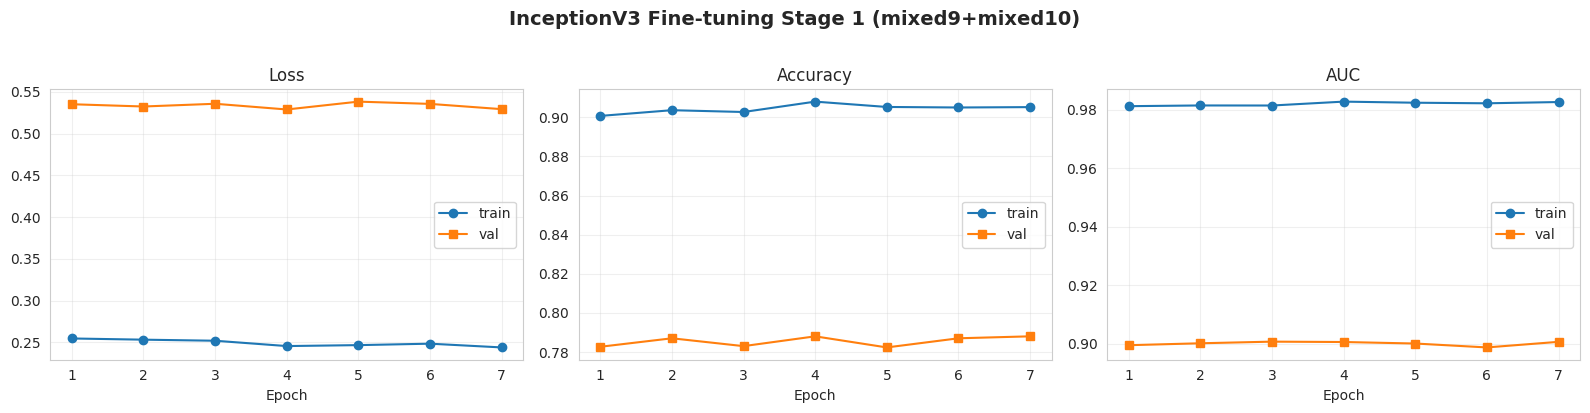

In [33]:
import matplotlib.pyplot as plt

def plot_history(hist, title="Training Curves"):
    h = hist.history
    epochs = range(1, len(h["loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    axes[0].plot(epochs, h["loss"], label="train", marker='o')
    axes[0].plot(epochs, h["val_loss"], label="val", marker='s')
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, h["accuracy"], label="train", marker='o')
    axes[1].plot(epochs, h["val_accuracy"], label="val", marker='s')
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(epochs, h["auc"], label="train", marker='o')
    axes[2].plot(epochs, h["val_auc"], label="val", marker='s')
    axes[2].set_title("AUC")
    axes[2].set_xlabel("Epoch")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

plot_history(history_ft_stage1, "InceptionV3 Fine-tuning Stage 1 (mixed9+mixed10)")

📊 EVALUATION: FINE-TUNING STAGE 1 (mixed9+mixed10 unfrozen)
94/94 ━━━━━━━━━━━━━━━━━━━━ 37s 335ms/step

🔹 SLICE-LEVEL RESULTS (FT Stage 1)
Accuracy: 80.04%

              precision    recall  f1-score   support

         GLI     0.8658    0.8392    0.8523      1860
        METS     0.8026    0.8613    0.8309       656
       OTHER     0.5562    0.5667    0.5614       480

    accuracy                         0.8004      2996
   macro avg     0.7415    0.7557    0.7482      2996
weighted avg     0.8023    0.8004    0.8010      2996



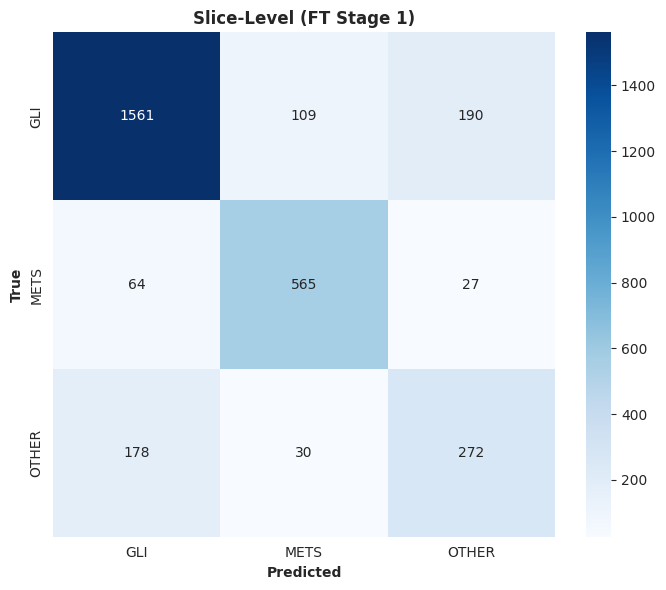

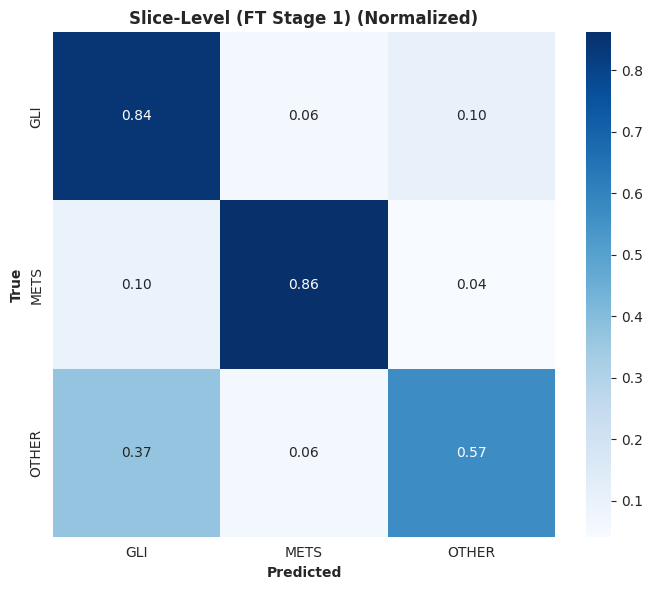


🔹 CASE-LEVEL RESULTS (FT Stage 1, Voting)
Accuracy: 88.72%

              precision    recall  f1-score   support

         GLI     0.9293    0.9194    0.9243       186
        METS     0.8444    0.9268    0.8837        41
       OTHER     0.6786    0.6333    0.6552        30

    accuracy                         0.8872       257
   macro avg     0.8175    0.8265    0.8211       257
weighted avg     0.8865    0.8872    0.8864       257



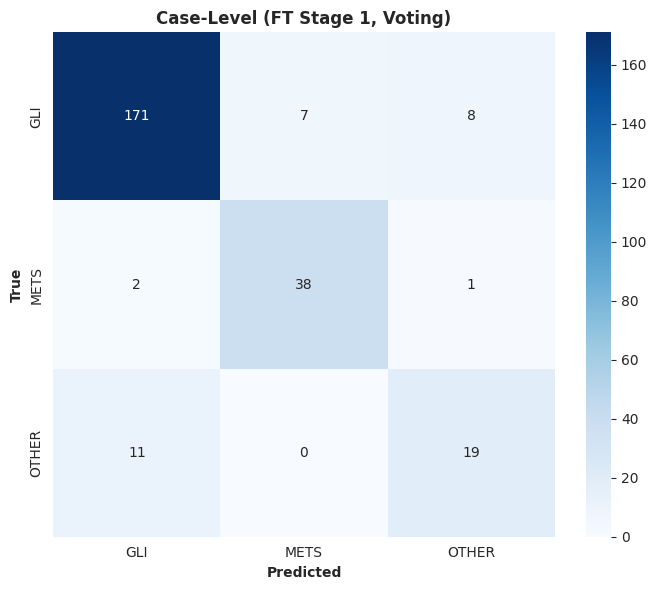

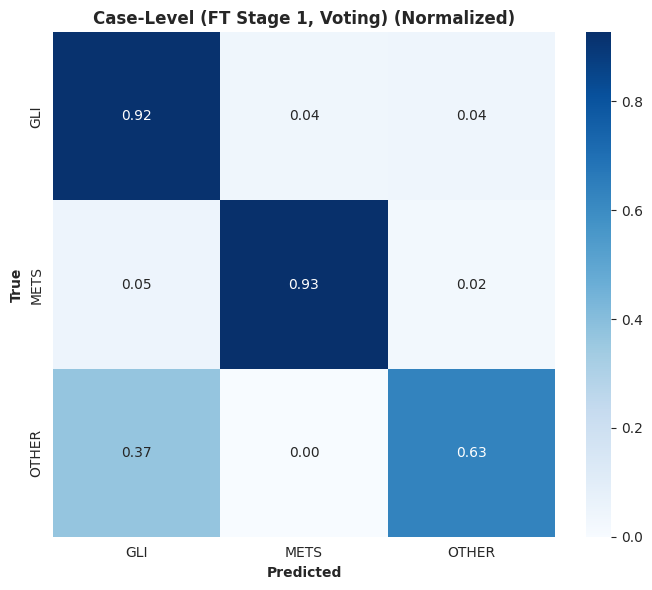

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

CLASS_NAMES = ["GLI", "METS", "OTHER"]

def plot_cm(y_true, y_pred, title, normalize=False):
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype("float") / (cm.sum(axis=1, keepdims=True) + 1e-12)

    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt=".2f" if normalize else "d",
                cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(title + (" (Normalized)" if normalize else ""), fontweight="bold")
    plt.xlabel("Predicted", fontweight="bold")
    plt.ylabel("True", fontweight="bold")
    plt.tight_layout()
    plt.show()

def predict_with_metadata(model, gen):
    y_prob = model.predict(gen, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)
    case_keys = [ck for (ck, local_idx, lbl) in gen.samples]
    y_true = np.array([lbl for (ck, local_idx, lbl) in gen.samples], dtype=np.int32)
    return y_true, y_pred, y_prob, case_keys

def majority_vote(arr, n_classes=3):
    counts = np.bincount(arr, minlength=n_classes)
    top = counts.max()
    tied = np.where(counts == top)[0]
    return int(tied[0])

def case_level_vote(y_pred_slice, case_keys, clean_case_index):
    df = pd.DataFrame({"case_key": case_keys, "pred": y_pred_slice})
    y_pred_case = df.groupby("case_key")["pred"].apply(lambda s: majority_vote(s.values, n_classes=3))
    y_true_case = y_pred_case.index.to_series().apply(lambda ck: clean_case_index[ck]["class_label"])
    return y_true_case.values.astype(int), y_pred_case.values.astype(int)

print("=" * 70)
print("📊 EVALUATION: FINE-TUNING STAGE 1 (mixed9+mixed10 unfrozen)")
print("=" * 70)

# Slice-level
y_true_slice, y_pred_slice, _, case_keys = predict_with_metadata(model_inception, test_gen)

print("\n" + "="*70)
print("🔹 SLICE-LEVEL RESULTS (FT Stage 1)")
print("="*70)
print(f"Accuracy: {accuracy_score(y_true_slice, y_pred_slice)*100:.2f}%\n")
print(classification_report(y_true_slice, y_pred_slice, target_names=CLASS_NAMES, digits=4))

plot_cm(y_true_slice, y_pred_slice, "Slice-Level (FT Stage 1)", normalize=False)
plot_cm(y_true_slice, y_pred_slice, "Slice-Level (FT Stage 1)", normalize=True)

# Case-level
y_true_case, y_pred_case = case_level_vote(y_pred_slice, case_keys, clean_case_index)

print("\n" + "="*70)
print("🔹 CASE-LEVEL RESULTS (FT Stage 1, Voting)")
print("="*70)
print(f"Accuracy: {accuracy_score(y_true_case, y_pred_case)*100:.2f}%\n")
print(classification_report(y_true_case, y_pred_case, target_names=CLASS_NAMES, digits=4))

plot_cm(y_true_case, y_pred_case, "Case-Level (FT Stage 1, Voting)", normalize=False)
plot_cm(y_true_case, y_pred_case, "Case-Level (FT Stage 1, Voting)", normalize=True)

# Stage 2 Fine Tuning

In [35]:
print("\n🚀 Stage 2: Deeper Fine-Tuning")

# Unfreeze selected inception blocks
for layer in inception_base.layers:
    if any(block in layer.name for block in ["mixed7", "mixed8", "mixed9", "mixed10"]):
        layer.trainable = True
    else:
        layer.trainable = False



🚀 Stage 2: Deeper Fine-Tuning


In [36]:
trainable_layers = [l.name for l in inception_base.layers if l.trainable]

print(f"✅ Trainable layers in Stage 2: {len(trainable_layers)}")
print("📋 Sample trainable layers:")
print(trainable_layers[:5], " ... ", trainable_layers[-5:])


✅ Trainable layers in Stage 2: 6
📋 Sample trainable layers:
['mixed7', 'mixed8', 'mixed9_0', 'mixed9', 'mixed9_1']  ...  ['mixed8', 'mixed9_0', 'mixed9', 'mixed9_1', 'mixed10']


In [38]:
model_inception.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",   # or binary_crossentropy
    metrics=["accuracy"]
)


In [40]:
history_ft_stage2 = model_inception.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FT_STAGE1,
    callbacks=callbacks_ft1,
    verbose=1
)

print("\n✅ Fine-tuning Stage 2 complete!")


Epoch 1/20
813/813 ━━━━━━━━━━━━━━━━━━━━ 193s 219ms/step - accuracy: 0.9037 - loss: 0.2486 - val_accuracy: 0.7887 - val_loss: 0.5300 - learning_rate: 1.0000e-05
Epoch 2/20
813/813 ━━━━━━━━━━━━━━━━━━━━ 155s 190ms/step - accuracy: 0.9025 - loss: 0.2502 - val_accuracy: 0.7877 - val_loss: 0.5270 - learning_rate: 1.0000e-05
Epoch 3/20
813/813 ━━━━━━━━━━━━━━━━━━━━ 154s 189ms/step - accuracy: 0.9055 - loss: 0.2494 - val_accuracy: 0.7814 - val_loss: 0.5351 - learning_rate: 1.0000e-05
Epoch 4/20
813/813 ━━━━━━━━━━━━━━━━━━━━ 158s 194ms/step - accuracy: 0.9037 - loss: 0.2483 - val_accuracy: 0.7887 - val_loss: 0.5271 - learning_rate: 1.0000e-05
Epoch 5/20
813/813 ━━━━━━━━━━━━━━━━━━━━ 177s 218ms/step - accuracy: 0.9069 - loss: 0.2434 - val_accuracy: 0.7874 - val_loss: 0.5296 - learning_rate: 1.0000e-05
Epoch 6/20
813/813 ━━━━━━━━━━━━━━━━━━━━ 177s 218ms/step - accuracy: 0.9085 - loss: 0.2475 - val_accuracy: 0.7867 - val_loss: 0.5329 - learning_rate: 1.0000e-05
Epoch 7/20
813/813 ━━━━━━━━━━━━━━━━━━━━ 

KeyboardInterrupt: 

#  Summary (Fill it manually)

In [ ]:
import pandas as pd

# Manually fill in your results from Stage 0, Stage 1, and Stage 2
inception_results = pd.DataFrame({
    "Stage": ["Stage 0 (Frozen)", "FT Stage 1 (mixed9+10)", "FT Stage 2 (mixed7+8+9+10)"],
    "Slice Accuracy (%)": [0.0, 0.0, 0.0],  # Fill in your actual values
    "Case Accuracy (%)": [0.0, 0.0, 0.0],   # Fill in your actual values
    "GLI F1": [0.0, 0.0, 0.0],
    "METS F1": [0.0, 0.0, 0.0],
    "OTHER F1": [0.0, 0.0, 0.0]
})

print("\n" + "="*70)
print("📊 INCEPTIONV3 TRAINING SUMMARY")
print("="*70)
print(inception_results.to_string(index=False))

# custom CNN

In [22]:
import tensorflow as tf
from tensorflow.keras import layers, Model

IMG_HEIGHT = 240
IMG_WIDTH = 240
NUM_CLASSES = 3

def build_custom_cnn_4ch(input_shape=(IMG_HEIGHT, IMG_WIDTH, 4),
                         dropout1=0.5,
                         dropout2=0.4,
                         l2_reg=1e-4):
    """
    Custom CNN for 4-channel MRI input (T1n, T1c, T2w, T2f)
    with 3-class output (GLI, METS, OTHER).
    
    Architecture:
    - Block 1: 2x Conv(32) + MaxPool
    - Block 2: 2x Conv(64) + MaxPool
    - Block 3: 3x Conv(128) + MaxPool
    - Block 4: 3x Conv(256) + MaxPool
    - Block 5: 3x Conv(512) + MaxPool
    - Classification head (same as transfer learning models)
    
    Args:
        input_shape: (240, 240, 4)
        dropout1: First dropout rate in classification head
        dropout2: Second dropout rate in classification head
        l2_reg: L2 regularization factor
    
    Returns:
        Keras Model
    """
    
    regularizer = tf.keras.regularizers.l2(l2_reg)
    
    inp = layers.Input(shape=input_shape, name="input_4ch")
    
    # ========== Block 1: 32 filters ==========
    x = layers.Conv2D(32, (3, 3), padding="same", kernel_regularizer=regularizer, name="block1_conv1")(inp)
    x = layers.BatchNormalization(name="block1_bn1")(x)
    x = layers.Activation("relu", name="block1_relu1")(x)
    
    x = layers.Conv2D(32, (3, 3), padding="same", kernel_regularizer=regularizer, name="block1_conv2")(x)
    x = layers.BatchNormalization(name="block1_bn2")(x)
    x = layers.Activation("relu", name="block1_relu2")(x)
    
    x = layers.MaxPooling2D((2, 2), name="block1_pool")(x)  # 240 → 120
    x = layers.Dropout(0.2, name="block1_dropout")(x)
    
    # ========== Block 2: 64 filters ==========
    x = layers.Conv2D(64, (3, 3), padding="same", kernel_regularizer=regularizer, name="block2_conv1")(x)
    x = layers.BatchNormalization(name="block2_bn1")(x)
    x = layers.Activation("relu", name="block2_relu1")(x)
    
    x = layers.Conv2D(64, (3, 3), padding="same", kernel_regularizer=regularizer, name="block2_conv2")(x)
    x = layers.BatchNormalization(name="block2_bn2")(x)
    x = layers.Activation("relu", name="block2_relu2")(x)
    
    x = layers.MaxPooling2D((2, 2), name="block2_pool")(x)  # 120 → 60
    x = layers.Dropout(0.2, name="block2_dropout")(x)
    
    # ========== Block 3: 128 filters ==========
    x = layers.Conv2D(128, (3, 3), padding="same", kernel_regularizer=regularizer, name="block3_conv1")(x)
    x = layers.BatchNormalization(name="block3_bn1")(x)
    x = layers.Activation("relu", name="block3_relu1")(x)
    
    x = layers.Conv2D(128, (3, 3), padding="same", kernel_regularizer=regularizer, name="block3_conv2")(x)
    x = layers.BatchNormalization(name="block3_bn2")(x)
    x = layers.Activation("relu", name="block3_relu2")(x)
    
    x = layers.Conv2D(128, (3, 3), padding="same", kernel_regularizer=regularizer, name="block3_conv3")(x)
    x = layers.BatchNormalization(name="block3_bn3")(x)
    x = layers.Activation("relu", name="block3_relu3")(x)
    
    x = layers.MaxPooling2D((2, 2), name="block3_pool")(x)  # 60 → 30
    x = layers.Dropout(0.3, name="block3_dropout")(x)
    
    # ========== Block 4: 256 filters ==========
    x = layers.Conv2D(256, (3, 3), padding="same", kernel_regularizer=regularizer, name="block4_conv1")(x)
    x = layers.BatchNormalization(name="block4_bn1")(x)
    x = layers.Activation("relu", name="block4_relu1")(x)
    
    x = layers.Conv2D(256, (3, 3), padding="same", kernel_regularizer=regularizer, name="block4_conv2")(x)
    x = layers.BatchNormalization(name="block4_bn2")(x)
    x = layers.Activation("relu", name="block4_relu2")(x)
    
    x = layers.Conv2D(256, (3, 3), padding="same", kernel_regularizer=regularizer, name="block4_conv3")(x)
    x = layers.BatchNormalization(name="block4_bn3")(x)
    x = layers.Activation("relu", name="block4_relu3")(x)
    
    x = layers.MaxPooling2D((2, 2), name="block4_pool")(x)  # 30 → 15
    x = layers.Dropout(0.3, name="block4_dropout")(x)
    
    # ========== Block 5: 512 filters ==========
    x = layers.Conv2D(512, (3, 3), padding="same", kernel_regularizer=regularizer, name="block5_conv1")(x)
    x = layers.BatchNormalization(name="block5_bn1")(x)
    x = layers.Activation("relu", name="block5_relu1")(x)
    
    x = layers.Conv2D(512, (3, 3), padding="same", kernel_regularizer=regularizer, name="block5_conv2")(x)
    x = layers.BatchNormalization(name="block5_bn2")(x)
    x = layers.Activation("relu", name="block5_relu2")(x)
    
    x = layers.Conv2D(512, (3, 3), padding="same", kernel_regularizer=regularizer, name="block5_conv3")(x)
    x = layers.BatchNormalization(name="block5_bn3")(x)
    x = layers.Activation("relu", name="block5_relu3")(x)
    
    x = layers.MaxPooling2D((2, 2), name="block5_pool")(x)  # 15 → 7
    x = layers.Dropout(0.4, name="block5_dropout")(x)
    
    # ========== Classification Head (same as transfer learning models) ==========
    h = layers.GlobalAveragePooling2D(name="gap")(x)
    h = layers.Dropout(dropout1, name="drop1")(h)
    h = layers.Dense(256, activation="relu", kernel_regularizer=regularizer, name="fc1")(h)
    h = layers.Dropout(dropout2, name="drop2")(h)
    out = layers.Dense(NUM_CLASSES, activation="softmax", name="pred")(h)
    
    model = Model(inputs=inp, outputs=out, name="CustomCNN_4ch_3class")
    return model

# Build the model
model_cnn = build_custom_cnn_4ch(dropout1=0.5, dropout2=0.4)

print("✅ Custom CNN model created successfully!")
print(f"   Architecture: 5 conv blocks (32→64→128→256→512) + classification head")
print(f"   Total params: ~{model_cnn.count_params():,}")

✅ Custom CNN model created successfully!
   Architecture: 5 conv blocks (32→64→128→256→512) + classification head
   Total params: ~7,953,603


In [23]:
multi_auc = tf.keras.metrics.AUC(
    multi_label=True, 
    num_labels=NUM_CLASSES, 
    name="auc"
)

model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),  # Higher LR for scratch training
    loss="categorical_crossentropy",
    metrics=["accuracy", multi_auc]
)

print("✅ Model compiled with Adam (lr=1e-3), categorical_crossentropy, and AUC metric")

✅ Model compiled with Adam (lr=1e-3), categorical_crossentropy, and AUC metric


In [24]:
model_cnn.summary()

Model: "CustomCNN_4ch_3class"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_4ch (InputLayer)          │ (None, 240, 240, 4)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 240, 240, 32)   │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn1 (BatchNormalization) │ (None, 240, 240, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu1 (Activation)       │ (None, 240, 240, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 240, 240, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn2 (BatchNormalization) │ (None, 240, 240, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu2 (Activation)       │ (None, 240, 240, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 120, 120, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_dropout (Dropout)        │ (None, 120, 120, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 120, 120, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn1 (BatchNormalization) │ (None, 120, 120, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu1 (Activation)       │ (None, 120, 120, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 120, 120, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn2 (BatchNormalization) │ (None, 120, 120, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu2 (Activation)       │ (None, 120, 120, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 60, 60, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_dropout (Dropout)        │ (None, 60, 60, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn1 (BatchNormalization) │ (None, 60, 60, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu1 (Activation)       │ (None, 60, 60, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 60, 60, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn2 (BatchNormalization) │ (None, 60, 60, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu2 (Activation)       │ (None, 60, 60, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 60, 60, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn3 (BatchNormalization) │ (None, 60, 60, 128)    │           51

 Total params: 7,953,603 (30.34 MB)

 Trainable params: 7,947,843 (30.32 MB)

 Non-trainable params: 5,760 (22.50 KB)

In [25]:
# Test forward pass
xb, yb = train_gen[0]
print("Input batch shape:", xb.shape, "| Range:", xb.min(), "-", xb.max())
print("Label batch shape:", yb.shape, "| Classes in batch:", sorted(set(yb.argmax(axis=1))))

pred = model_cnn(xb[:2])
print("Prediction shape:", pred.shape)
print("Prediction row sums (should be ~1.0):", tf.reduce_sum(pred, axis=1).numpy())

Input batch shape: (32, 240, 240, 4) | Range: 0.0 - 1.0
Label batch shape: (32, 3) | Classes in batch: [np.int64(0), np.int64(1), np.int64(2)]


I0000 00:00:1770148671.347675      55 cuda_dnn.cc:529] Loaded cuDNN version 91002


Prediction shape: (2, 3)
Prediction row sums (should be ~1.0): [1. 1.]


In [26]:
EPOCHS_STAGE0 = 50  # More epochs needed for scratch training (vs 30 for transfer learning)

ckpt_path_stage0 = "custom_cnn_3class_stage0_best.keras"

callbacks_stage0 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=10,  # More patience for scratch training
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=5,  # More patience
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        ckpt_path_stage0,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]

print("✅ Callbacks configured:")
print("   - EarlyStopping: patience=10 on val_auc (more patience for scratch training)")
print("   - ReduceLROnPlateau: factor=0.5, patience=5")
print("   - ModelCheckpoint: saves best val_auc model")

✅ Callbacks configured:
   - EarlyStopping: patience=10 on val_auc (more patience for scratch training)
   - ReduceLROnPlateau: factor=0.5, patience=5
   - ModelCheckpoint: saves best val_auc model


In [27]:
print("🚀 Starting Stage 0 training (Custom CNN from scratch)...")
print(f"   Training: ALL layers (~{model_cnn.count_params():,} params)")
print(f"   No pretrained weights - training from random initialization")
print(f"   Epochs: {EPOCHS_STAGE0}")
print(f"   Learning rate: 1e-3 (higher for scratch training)")
print(f"   Regularization: L2 + Dropout + BatchNorm")
print(f"   Expected training time: ~3-4 min/epoch\n")

history_stage0 = model_cnn.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_STAGE0,
    callbacks=callbacks_stage0,
    verbose=1
)

print("\n✅ Stage 0 training complete!")

🚀 Starting Stage 0 training (Custom CNN from scratch)...
   Training: ALL layers (~7,953,603 params)
   No pretrained weights - training from random initialization
   Epochs: 50
   Learning rate: 1e-3 (higher for scratch training)
   Regularization: L2 + Dropout + BatchNorm
   Expected training time: ~3-4 min/epoch

Epoch 1/50


I0000 00:00:1770148706.554729     185 service.cc:152] XLA service 0x7dcbd0004a70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770148706.554768     185 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


  1/813 ━━━━━━━━━━━━━━━━━━━━ 6:36:32 29s/step - accuracy: 0.3438 - auc: 0.4156 - loss: 2.3828

I0000 00:00:1770148726.997939     185 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


813/813 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.6532 - auc: 0.8215 - loss: 1.0481
Epoch 1: val_auc improved from -inf to 0.50000, saving model to custom_cnn_3class_stage0_best.keras
813/813 ━━━━━━━━━━━━━━━━━━━━ 287s 318ms/step - accuracy: 0.6533 - auc: 0.8216 - loss: 1.0479 - val_accuracy: 0.1602 - val_auc: 0.5000 - val_loss: 13.5251 - learning_rate: 0.0010
Epoch 2/50
813/813 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.8113 - auc: 0.9353 - loss: 0.6279
Epoch 2: val_auc improved from 0.50000 to 0.83812, saving model to custom_cnn_3class_stage0_best.keras
813/813 ━━━━━━━━━━━━━━━━━━━━ 176s 217ms/step - accuracy: 0.8113 - auc: 0.9353 - loss: 0.6279 - val_accuracy: 0.7373 - val_auc: 0.8381 - val_loss: 1.2219 - learning_rate: 0.0010
Epoch 3/50
813/813 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.8581 - auc: 0.9616 - loss: 0.4913
Epoch 3: val_auc did not improve from 0.83812
813/813 ━━━━━━━━━━━━━━━━━━━━ 162s 200ms/step - accuracy: 0.8581 - auc: 0.9616 - loss: 0.4913 - val_ac

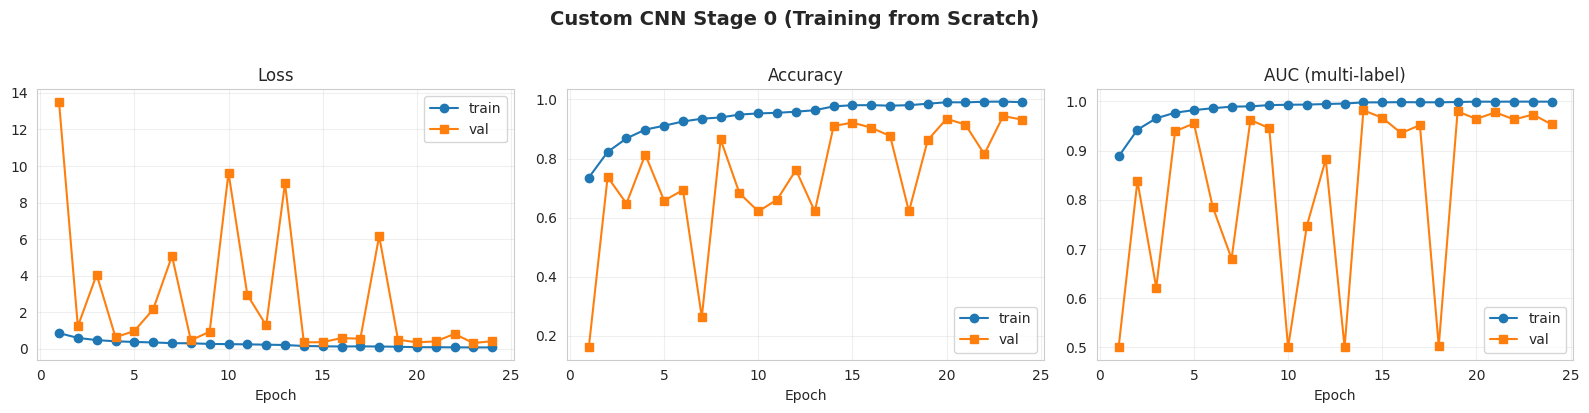

In [28]:
import matplotlib.pyplot as plt

def plot_history(hist, title="Training Curves"):
    h = hist.history
    epochs = range(1, len(h["loss"]) + 1)
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    # Loss
    axes[0].plot(epochs, h["loss"], label="train", marker='o')
    axes[0].plot(epochs, h["val_loss"], label="val", marker='s')
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[1].plot(epochs, h["accuracy"], label="train", marker='o')
    axes[1].plot(epochs, h["val_accuracy"], label="val", marker='s')
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # AUC
    axes[2].plot(epochs, h["auc"], label="train", marker='o')
    axes[2].plot(epochs, h["val_auc"], label="val", marker='s')
    axes[2].set_title("AUC (multi-label)")
    axes[2].set_xlabel("Epoch")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

plot_history(history_stage0, "Custom CNN Stage 0 (Training from Scratch)")

📊 EVALUATION: STAGE 0 (Custom CNN from Scratch)
94/94 ━━━━━━━━━━━━━━━━━━━━ 89s 943ms/step

🔹 SLICE-LEVEL RESULTS (Stage 0)
Accuracy: 90.82%

              precision    recall  f1-score   support

         GLI     0.9596    0.8941    0.9257      1860
        METS     0.8596    0.9985    0.9238       656
       OTHER     0.8044    0.8396    0.8216       480

    accuracy                         0.9082      2996
   macro avg     0.8745    0.9107    0.8904      2996
weighted avg     0.9128    0.9082    0.9086      2996



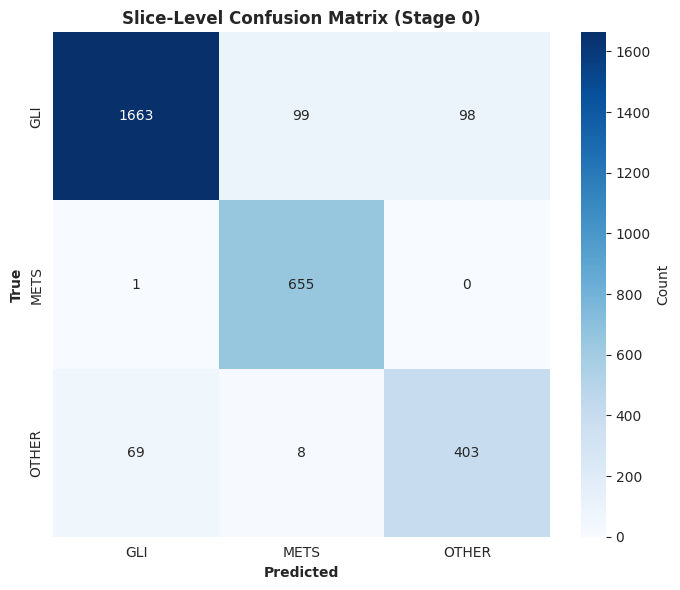

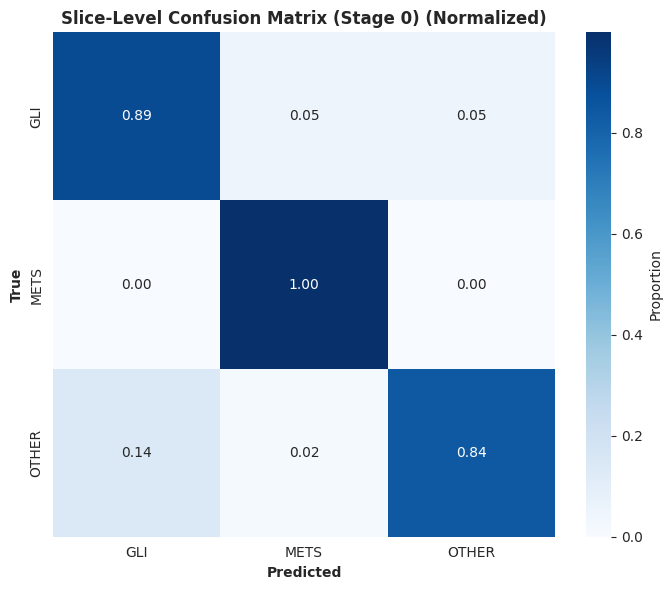


🔹 CASE-LEVEL RESULTS (Majority Voting - Stage 0)
Accuracy: 93.39%

              precision    recall  f1-score   support

         GLI     0.9721    0.9355    0.9534       186
        METS     0.8542    1.0000    0.9213        41
       OTHER     0.8333    0.8333    0.8333        30

    accuracy                         0.9339       257
   macro avg     0.8865    0.9229    0.9027       257
weighted avg     0.9371    0.9339    0.9343       257



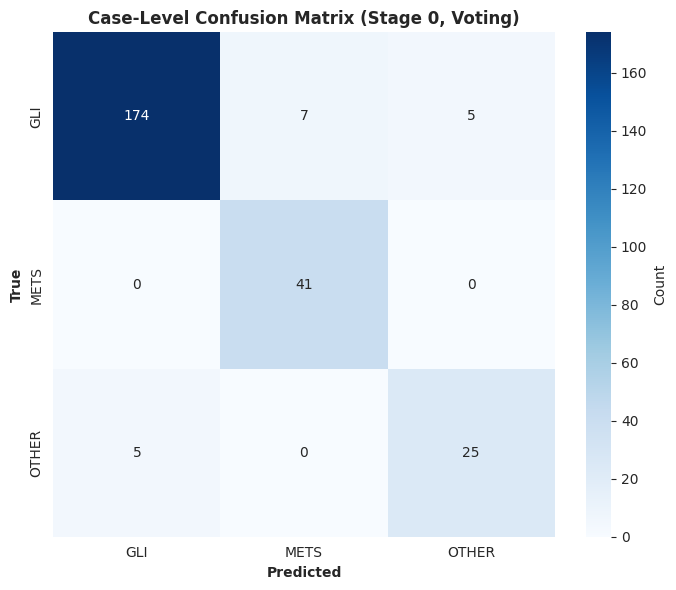

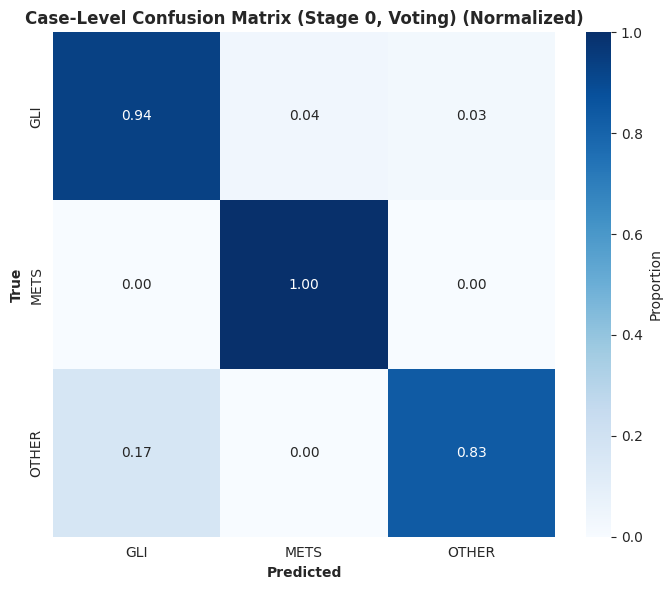

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

CLASS_NAMES = ["GLI", "METS", "OTHER"]

def plot_cm(y_true, y_pred, title, normalize=False):
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype("float") / (cm.sum(axis=1, keepdims=True) + 1e-12)
    
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm, annot=True, 
        fmt=".2f" if normalize else "d",
        cmap="Blues", 
        xticklabels=CLASS_NAMES, 
        yticklabels=CLASS_NAMES,
        cbar_kws={'label': 'Count' if not normalize else 'Proportion'}
    )
    plt.title(title + (" (Normalized)" if normalize else ""), fontweight="bold")
    plt.xlabel("Predicted", fontweight="bold")
    plt.ylabel("True", fontweight="bold")
    plt.tight_layout()
    plt.show()

def predict_with_metadata(model, gen):
    y_prob = model.predict(gen, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)
    case_keys = [ck for (ck, local_idx, lbl) in gen.samples]
    y_true = np.array([lbl for (ck, local_idx, lbl) in gen.samples], dtype=np.int32)
    return y_true, y_pred, y_prob, case_keys

def majority_vote(arr, n_classes=3):
    counts = np.bincount(arr, minlength=n_classes)
    top = counts.max()
    tied = np.where(counts == top)[0]
    return int(tied[0])

def case_level_vote(y_pred_slice, case_keys, clean_case_index):
    df = pd.DataFrame({"case_key": case_keys, "pred": y_pred_slice})
    y_pred_case = df.groupby("case_key")["pred"].apply(
        lambda s: majority_vote(s.values, n_classes=3)
    )
    y_true_case = y_pred_case.index.to_series().apply(
        lambda ck: clean_case_index[ck]["class_label"]
    )
    return y_true_case.values.astype(int), y_pred_case.values.astype(int)

# ----- Evaluate on test set -----
print("=" * 70)
print("📊 EVALUATION: STAGE 0 (Custom CNN from Scratch)")
print("=" * 70)

eval_gen = test_gen  # must have shuffle=False

# Slice-level
y_true_slice, y_pred_slice, _, case_keys = predict_with_metadata(model_cnn, eval_gen)

print("\n" + "="*70)
print("🔹 SLICE-LEVEL RESULTS (Stage 0)")
print("="*70)
print(f"Accuracy: {accuracy_score(y_true_slice, y_pred_slice)*100:.2f}%\n")
print(classification_report(y_true_slice, y_pred_slice, target_names=CLASS_NAMES, digits=4))

plot_cm(y_true_slice, y_pred_slice, "Slice-Level Confusion Matrix (Stage 0)", normalize=False)
plot_cm(y_true_slice, y_pred_slice, "Slice-Level Confusion Matrix (Stage 0)", normalize=True)

# Case-level (majority voting)
y_true_case, y_pred_case = case_level_vote(y_pred_slice, case_keys, clean_case_index)

print("\n" + "="*70)
print("🔹 CASE-LEVEL RESULTS (Majority Voting - Stage 0)")
print("="*70)
print(f"Accuracy: {accuracy_score(y_true_case, y_pred_case)*100:.2f}%\n")
print(classification_report(y_true_case, y_pred_case, target_names=CLASS_NAMES, digits=4))

plot_cm(y_true_case, y_pred_case, "Case-Level Confusion Matrix (Stage 0, Voting)", normalize=False)
plot_cm(y_true_case, y_pred_case, "Case-Level Confusion Matrix (Stage 0, Voting)", normalize=True)

# Fine Tuning

In [30]:
import tensorflow as tf
import keras

# Enable unsafe deserialization
keras.config.enable_unsafe_deserialization()

NUM_CLASSES = 3
multi_auc = tf.keras.metrics.AUC(multi_label=True, num_labels=NUM_CLASSES, name="auc")

# Load the best Stage 0 model
model_cnn = keras.models.load_model(
    "custom_cnn_3class_stage0_best.keras",
    custom_objects={"auc": multi_auc}
)

print("✅ Custom CNN Stage 0 model loaded successfully!")
print(f"   Total params: {model_cnn.count_params():,}")

✅ Custom CNN Stage 0 model loaded successfully!
   Total params: 7,953,603


In [31]:
from tensorflow.keras import layers, Model

def build_custom_cnn_4ch(input_shape=(240, 240, 4),
                         dropout1=0.3,  # Reduced from 0.5
                         dropout2=0.2,  # Reduced from 0.4
                         l2_reg=1e-4):
    """
    Custom CNN for Stage 1 - same architecture, reduced dropout
    """
    
    regularizer = tf.keras.regularizers.l2(l2_reg)
    
    inp = layers.Input(shape=input_shape, name="input_4ch")
    
    # ========== Block 1: 32 filters ==========
    x = layers.Conv2D(32, (3, 3), padding="same", kernel_regularizer=regularizer, name="block1_conv1")(inp)
    x = layers.BatchNormalization(name="block1_bn1")(x)
    x = layers.Activation("relu", name="block1_relu1")(x)
    
    x = layers.Conv2D(32, (3, 3), padding="same", kernel_regularizer=regularizer, name="block1_conv2")(x)
    x = layers.BatchNormalization(name="block1_bn2")(x)
    x = layers.Activation("relu", name="block1_relu2")(x)
    
    x = layers.MaxPooling2D((2, 2), name="block1_pool")(x)
    x = layers.Dropout(0.15, name="block1_dropout")(x)  # Reduced from 0.2
    
    # ========== Block 2: 64 filters ==========
    x = layers.Conv2D(64, (3, 3), padding="same", kernel_regularizer=regularizer, name="block2_conv1")(x)
    x = layers.BatchNormalization(name="block2_bn1")(x)
    x = layers.Activation("relu", name="block2_relu1")(x)
    
    x = layers.Conv2D(64, (3, 3), padding="same", kernel_regularizer=regularizer, name="block2_conv2")(x)
    x = layers.BatchNormalization(name="block2_bn2")(x)
    x = layers.Activation("relu", name="block2_relu2")(x)
    
    x = layers.MaxPooling2D((2, 2), name="block2_pool")(x)
    x = layers.Dropout(0.15, name="block2_dropout")(x)  # Reduced from 0.2
    
    # ========== Block 3: 128 filters ==========
    x = layers.Conv2D(128, (3, 3), padding="same", kernel_regularizer=regularizer, name="block3_conv1")(x)
    x = layers.BatchNormalization(name="block3_bn1")(x)
    x = layers.Activation("relu", name="block3_relu1")(x)
    
    x = layers.Conv2D(128, (3, 3), padding="same", kernel_regularizer=regularizer, name="block3_conv2")(x)
    x = layers.BatchNormalization(name="block3_bn2")(x)
    x = layers.Activation("relu", name="block3_relu2")(x)
    
    x = layers.Conv2D(128, (3, 3), padding="same", kernel_regularizer=regularizer, name="block3_conv3")(x)
    x = layers.BatchNormalization(name="block3_bn3")(x)
    x = layers.Activation("relu", name="block3_relu3")(x)
    
    x = layers.MaxPooling2D((2, 2), name="block3_pool")(x)
    x = layers.Dropout(0.2, name="block3_dropout")(x)  # Reduced from 0.3
    
    # ========== Block 4: 256 filters ==========
    x = layers.Conv2D(256, (3, 3), padding="same", kernel_regularizer=regularizer, name="block4_conv1")(x)
    x = layers.BatchNormalization(name="block4_bn1")(x)
    x = layers.Activation("relu", name="block4_relu1")(x)
    
    x = layers.Conv2D(256, (3, 3), padding="same", kernel_regularizer=regularizer, name="block4_conv2")(x)
    x = layers.BatchNormalization(name="block4_bn2")(x)
    x = layers.Activation("relu", name="block4_relu2")(x)
    
    x = layers.Conv2D(256, (3, 3), padding="same", kernel_regularizer=regularizer, name="block4_conv3")(x)
    x = layers.BatchNormalization(name="block4_bn3")(x)
    x = layers.Activation("relu", name="block4_relu3")(x)
    
    x = layers.MaxPooling2D((2, 2), name="block4_pool")(x)
    x = layers.Dropout(0.2, name="block4_dropout")(x)  # Reduced from 0.3
    
    # ========== Block 5: 512 filters ==========
    x = layers.Conv2D(512, (3, 3), padding="same", kernel_regularizer=regularizer, name="block5_conv1")(x)
    x = layers.BatchNormalization(name="block5_bn1")(x)
    x = layers.Activation("relu", name="block5_relu1")(x)
    
    x = layers.Conv2D(512, (3, 3), padding="same", kernel_regularizer=regularizer, name="block5_conv2")(x)
    x = layers.BatchNormalization(name="block5_bn2")(x)
    x = layers.Activation("relu", name="block5_relu2")(x)
    
    x = layers.Conv2D(512, (3, 3), padding="same", kernel_regularizer=regularizer, name="block5_conv3")(x)
    x = layers.BatchNormalization(name="block5_bn3")(x)
    x = layers.Activation("relu", name="block5_relu3")(x)
    
    x = layers.MaxPooling2D((2, 2), name="block5_pool")(x)
    x = layers.Dropout(0.3, name="block5_dropout")(x)  # Reduced from 0.4
    
    # ========== Classification Head ==========
    h = layers.GlobalAveragePooling2D(name="gap")(x)
    h = layers.Dropout(dropout1, name="drop1")(h)
    h = layers.Dense(256, activation="relu", kernel_regularizer=regularizer, name="fc1")(h)
    h = layers.Dropout(dropout2, name="drop2")(h)
    out = layers.Dense(NUM_CLASSES, activation="softmax", name="pred")(h)
    
    model = Model(inputs=inp, outputs=out, name="CustomCNN_4ch_3class")
    return model

# Build new model with reduced dropout
model_cnn_ft1 = build_custom_cnn_4ch(dropout1=0.3, dropout2=0.2)

print("✅ Stage 1 model built with reduced dropout:")
print("   Classification head: dropout1=0.3 (was 0.5), dropout2=0.2 (was 0.4)")
print("   Conv blocks: reduced dropout throughout")

✅ Stage 1 model built with reduced dropout:
   Classification head: dropout1=0.3 (was 0.5), dropout2=0.2 (was 0.4)
   Conv blocks: reduced dropout throughout


In [32]:
# Transfer weights from Stage 0 model to new model
print("🔄 Transferring weights from Stage 0 model...")

for layer_ft1 in model_cnn_ft1.layers:
    try:
        # Find matching layer in Stage 0 model by name
        layer_s0 = model_cnn.get_layer(layer_ft1.name)
        
        # Transfer weights
        weights_s0 = layer_s0.get_weights()
        if len(weights_s0) > 0:
            layer_ft1.set_weights(weights_s0)
            
    except ValueError:
        # Layer not found in Stage 0 model (e.g., Dropout with different rate)
        pass

print("✅ Weights transferred successfully!")

🔄 Transferring weights from Stage 0 model...
✅ Weights transferred successfully!


In [33]:
multi_auc = tf.keras.metrics.AUC(multi_label=True, num_labels=NUM_CLASSES, name="auc")

model_cnn_ft1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # 10x lower than Stage 0
    loss="categorical_crossentropy",
    metrics=["accuracy", multi_auc]
)

print("✅ Model recompiled with LR=1e-4 for fine-tuning Stage 1")

✅ Model recompiled with LR=1e-4 for fine-tuning Stage 1


In [34]:
EPOCHS_FT_STAGE1 = 30  # Fewer epochs than Stage 0

ckpt_path_ft1 = "custom_cnn_3class_finetune_stage1.keras"

callbacks_ft1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=4,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        ckpt_path_ft1,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]

print("🚀 Starting Fine-tuning Stage 1...")
print(f"   Changes from Stage 0:")
print(f"     - Learning rate: 1e-3 → 1e-4 (10x lower)")
print(f"     - Dropout: 0.5/0.4 → 0.3/0.2 (less regularization)")
print(f"     - Epochs: {EPOCHS_FT_STAGE1}")
print(f"   Goal: Fine-tune learned features with less regularization\n")

history_ft_stage1 = model_cnn_ft1.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FT_STAGE1,
    callbacks=callbacks_ft1,
    verbose=1
)

print("\n✅ Fine-tuning Stage 1 complete!")

🚀 Starting Fine-tuning Stage 1...
   Changes from Stage 0:
     - Learning rate: 1e-3 → 1e-4 (10x lower)
     - Dropout: 0.5/0.4 → 0.3/0.2 (less regularization)
     - Epochs: 30
   Goal: Fine-tune learned features with less regularization

Epoch 1/30
813/813 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.9912 - auc: 0.9992 - loss: 0.0998
Epoch 1: val_auc improved from -inf to 0.97008, saving model to custom_cnn_3class_finetune_stage1.keras
813/813 ━━━━━━━━━━━━━━━━━━━━ 203s 226ms/step - accuracy: 0.9912 - auc: 0.9992 - loss: 0.0998 - val_accuracy: 0.9389 - val_auc: 0.9701 - val_loss: 0.3463 - learning_rate: 1.0000e-04
Epoch 2/30
813/813 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.9909 - auc: 0.9996 - loss: 0.0860
Epoch 2: val_auc improved from 0.97008 to 0.98174, saving model to custom_cnn_3class_finetune_stage1.keras
813/813 ━━━━━━━━━━━━━━━━━━━━ 164s 201ms/step - accuracy: 0.9909 - auc: 0.9996 - loss: 0.0860 - val_accuracy: 0.9252 - val_auc: 0.9817 - val_loss: 0.3047 - learning

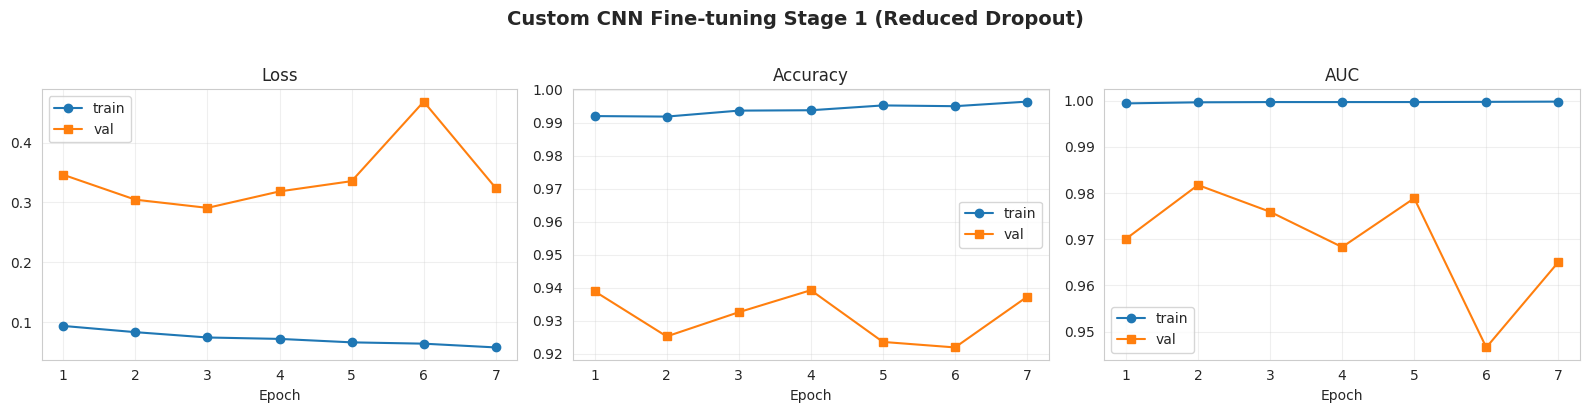

In [35]:
import matplotlib.pyplot as plt

def plot_history(hist, title="Training Curves"):
    h = hist.history
    epochs = range(1, len(h["loss"]) + 1)
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    axes[0].plot(epochs, h["loss"], label="train", marker='o')
    axes[0].plot(epochs, h["val_loss"], label="val", marker='s')
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(epochs, h["accuracy"], label="train", marker='o')
    axes[1].plot(epochs, h["val_accuracy"], label="val", marker='s')
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    axes[2].plot(epochs, h["auc"], label="train", marker='o')
    axes[2].plot(epochs, h["val_auc"], label="val", marker='s')
    axes[2].set_title("AUC")
    axes[2].set_xlabel("Epoch")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

plot_history(history_ft_stage1, "Custom CNN Fine-tuning Stage 1 (Reduced Dropout)")

📊 EVALUATION: FINE-TUNING STAGE 1 (Reduced Dropout)
94/94 ━━━━━━━━━━━━━━━━━━━━ 28s 286ms/step

🔹 SLICE-LEVEL RESULTS (FT Stage 1)
Accuracy: 94.03%

              precision    recall  f1-score   support

         GLI     0.9621    0.9409    0.9513      1860
        METS     0.9716    0.9893    0.9804       656
       OTHER     0.8212    0.8708    0.8453       480

    accuracy                         0.9403      2996
   macro avg     0.9183    0.9337    0.9257      2996
weighted avg     0.9416    0.9403    0.9407      2996



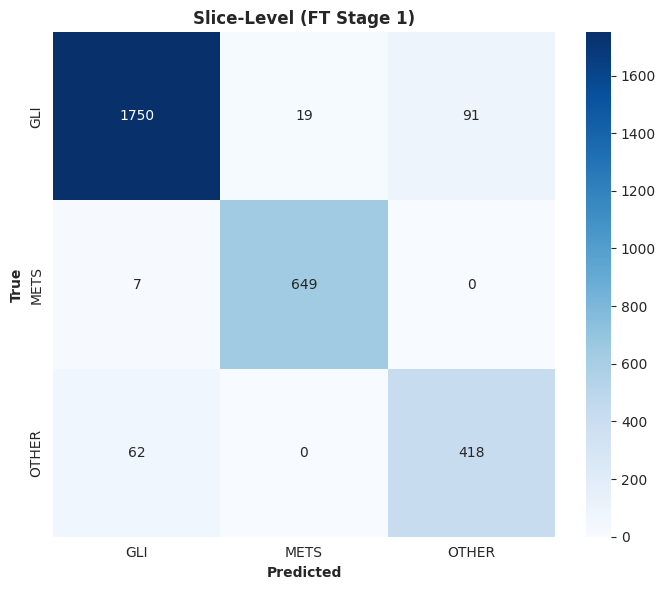

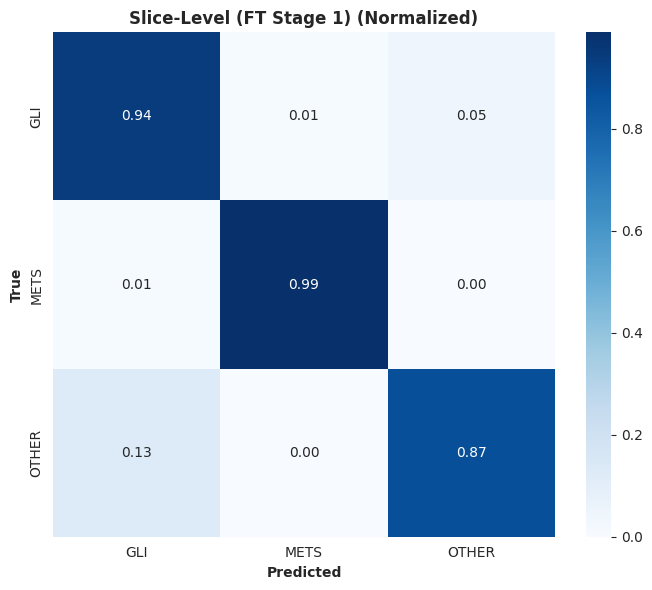


🔹 CASE-LEVEL RESULTS (FT Stage 1, Voting)
Accuracy: 96.50%

              precision    recall  f1-score   support

         GLI     0.9836    0.9677    0.9756       186
        METS     0.9762    1.0000    0.9880        41
       OTHER     0.8438    0.9000    0.8710        30

    accuracy                         0.9650       257
   macro avg     0.9345    0.9559    0.9448       257
weighted avg     0.9661    0.9650    0.9654       257



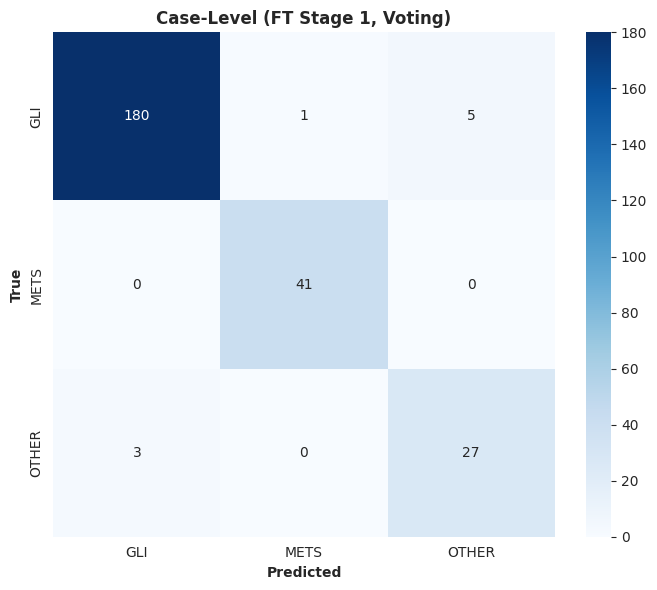

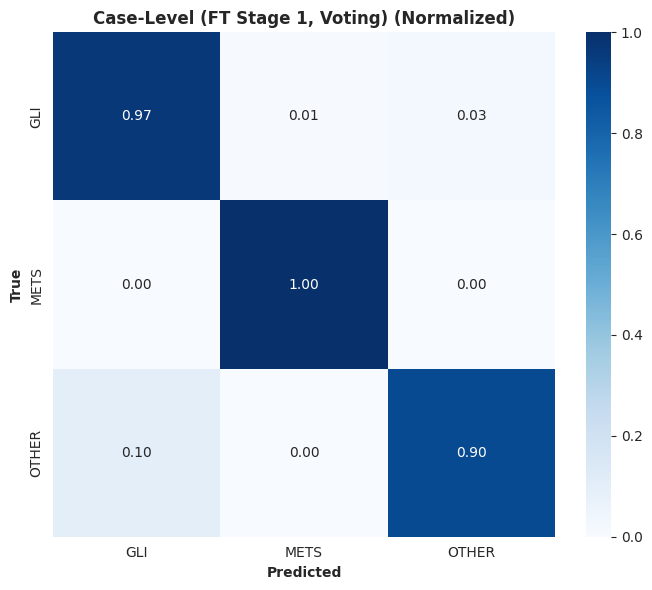

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

CLASS_NAMES = ["GLI", "METS", "OTHER"]

def plot_cm(y_true, y_pred, title, normalize=False):
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype("float") / (cm.sum(axis=1, keepdims=True) + 1e-12)
    
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt=".2f" if normalize else "d",
                cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(title + (" (Normalized)" if normalize else ""), fontweight="bold")
    plt.xlabel("Predicted", fontweight="bold")
    plt.ylabel("True", fontweight="bold")
    plt.tight_layout()
    plt.show()

def predict_with_metadata(model, gen):
    y_prob = model.predict(gen, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)
    case_keys = [ck for (ck, local_idx, lbl) in gen.samples]
    y_true = np.array([lbl for (ck, local_idx, lbl) in gen.samples], dtype=np.int32)
    return y_true, y_pred, y_prob, case_keys

def majority_vote(arr, n_classes=3):
    counts = np.bincount(arr, minlength=n_classes)
    top = counts.max()
    tied = np.where(counts == top)[0]
    return int(tied[0])

def case_level_vote(y_pred_slice, case_keys, clean_case_index):
    df = pd.DataFrame({"case_key": case_keys, "pred": y_pred_slice})
    y_pred_case = df.groupby("case_key")["pred"].apply(lambda s: majority_vote(s.values, n_classes=3))
    y_true_case = y_pred_case.index.to_series().apply(lambda ck: clean_case_index[ck]["class_label"])
    return y_true_case.values.astype(int), y_pred_case.values.astype(int)

print("=" * 70)
print("📊 EVALUATION: FINE-TUNING STAGE 1 (Reduced Dropout)")
print("=" * 70)

# Slice-level
y_true_slice, y_pred_slice, _, case_keys = predict_with_metadata(model_cnn_ft1, test_gen)

print("\n" + "="*70)
print("🔹 SLICE-LEVEL RESULTS (FT Stage 1)")
print("="*70)
print(f"Accuracy: {accuracy_score(y_true_slice, y_pred_slice)*100:.2f}%\n")
print(classification_report(y_true_slice, y_pred_slice, target_names=CLASS_NAMES, digits=4))

plot_cm(y_true_slice, y_pred_slice, "Slice-Level (FT Stage 1)", normalize=False)
plot_cm(y_true_slice, y_pred_slice, "Slice-Level (FT Stage 1)", normalize=True)

# Case-level
y_true_case, y_pred_case = case_level_vote(y_pred_slice, case_keys, clean_case_index)

print("\n" + "="*70)
print("🔹 CASE-LEVEL RESULTS (FT Stage 1, Voting)")
print("="*70)
print(f"Accuracy: {accuracy_score(y_true_case, y_pred_case)*100:.2f}%\n")
print(classification_report(y_true_case, y_pred_case, target_names=CLASS_NAMES, digits=4))

plot_cm(y_true_case, y_pred_case, "Case-Level (FT Stage 1, Voting)", normalize=False)
plot_cm(y_true_case, y_pred_case, "Case-Level (FT Stage 1, Voting)", normalize=True)

# Fine Tuning Stage 2

In [37]:
import os
import tensorflow as tf
import keras

keras.config.enable_unsafe_deserialization()

NUM_CLASSES = 3
multi_auc = tf.keras.metrics.AUC(multi_label=True, num_labels=NUM_CLASSES, name="auc")

# Prefer Stage 1; fallback to Stage 0
PATH_STAGE1 = "custom_cnn_3class_finetune_stage1.keras"
PATH_STAGE0 = "custom_cnn_3class_stage0_best.keras"

load_path = PATH_STAGE1 if os.path.exists(PATH_STAGE1) else PATH_STAGE0
print(f"📂 Loading model from: {load_path}")

model_cnn_loaded = keras.models.load_model(
    load_path,
    custom_objects={"auc": multi_auc}
)

print(f"✅ Model loaded: {model_cnn_loaded.name}")

📂 Loading model from: custom_cnn_3class_finetune_stage1.keras
✅ Model loaded: CustomCNN_4ch_3class


In [38]:
from tensorflow.keras import layers, Model

def build_custom_cnn_4ch(input_shape=(240, 240, 4),
                         dropout1=0.2,  # Minimal dropout (was 0.3 in Stage 1)
                         dropout2=0.1,  # Minimal dropout (was 0.2 in Stage 1)
                         l2_reg=5e-5):  # Reduced L2 regularization
    """
    Custom CNN for Stage 2 - same architecture, minimal dropout
    """
    
    regularizer = tf.keras.regularizers.l2(l2_reg)
    
    inp = layers.Input(shape=input_shape, name="input_4ch")
    
    # ========== Block 1: 32 filters ==========
    x = layers.Conv2D(32, (3, 3), padding="same", kernel_regularizer=regularizer, name="block1_conv1")(inp)
    x = layers.BatchNormalization(name="block1_bn1")(x)
    x = layers.Activation("relu", name="block1_relu1")(x)
    
    x = layers.Conv2D(32, (3, 3), padding="same", kernel_regularizer=regularizer, name="block1_conv2")(x)
    x = layers.BatchNormalization(name="block1_bn2")(x)
    x = layers.Activation("relu", name="block1_relu2")(x)
    
    x = layers.MaxPooling2D((2, 2), name="block1_pool")(x)
    x = layers.Dropout(0.1, name="block1_dropout")(x)  # Minimal
    
    # ========== Block 2: 64 filters ==========
    x = layers.Conv2D(64, (3, 3), padding="same", kernel_regularizer=regularizer, name="block2_conv1")(x)
    x = layers.BatchNormalization(name="block2_bn1")(x)
    x = layers.Activation("relu", name="block2_relu1")(x)
    
    x = layers.Conv2D(64, (3, 3), padding="same", kernel_regularizer=regularizer, name="block2_conv2")(x)
    x = layers.BatchNormalization(name="block2_bn2")(x)
    x = layers.Activation("relu", name="block2_relu2")(x)
    
    x = layers.MaxPooling2D((2, 2), name="block2_pool")(x)
    x = layers.Dropout(0.1, name="block2_dropout")(x)  # Minimal
    
    # ========== Block 3: 128 filters ==========
    x = layers.Conv2D(128, (3, 3), padding="same", kernel_regularizer=regularizer, name="block3_conv1")(x)
    x = layers.BatchNormalization(name="block3_bn1")(x)
    x = layers.Activation("relu", name="block3_relu1")(x)
    
    x = layers.Conv2D(128, (3, 3), padding="same", kernel_regularizer=regularizer, name="block3_conv2")(x)
    x = layers.BatchNormalization(name="block3_bn2")(x)
    x = layers.Activation("relu", name="block3_relu2")(x)
    
    x = layers.Conv2D(128, (3, 3), padding="same", kernel_regularizer=regularizer, name="block3_conv3")(x)
    x = layers.BatchNormalization(name="block3_bn3")(x)
    x = layers.Activation("relu", name="block3_relu3")(x)
    
    x = layers.MaxPooling2D((2, 2), name="block3_pool")(x)
    x = layers.Dropout(0.15, name="block3_dropout")(x)  # Minimal
    
    # ========== Block 4: 256 filters ==========
    x = layers.Conv2D(256, (3, 3), padding="same", kernel_regularizer=regularizer, name="block4_conv1")(x)
    x = layers.BatchNormalization(name="block4_bn1")(x)
    x = layers.Activation("relu", name="block4_relu1")(x)
    
    x = layers.Conv2D(256, (3, 3), padding="same", kernel_regularizer=regularizer, name="block4_conv2")(x)
    x = layers.BatchNormalization(name="block4_bn2")(x)
    x = layers.Activation("relu", name="block4_relu2")(x)
    
    x = layers.Conv2D(256, (3, 3), padding="same", kernel_regularizer=regularizer, name="block4_conv3")(x)
    x = layers.BatchNormalization(name="block4_bn3")(x)
    x = layers.Activation("relu", name="block4_relu3")(x)
    
    x = layers.MaxPooling2D((2, 2), name="block4_pool")(x)
    x = layers.Dropout(0.15, name="block4_dropout")(x)  # Minimal
    
    # ========== Block 5: 512 filters ==========
    x = layers.Conv2D(512, (3, 3), padding="same", kernel_regularizer=regularizer, name="block5_conv1")(x)
    x = layers.BatchNormalization(name="block5_bn1")(x)
    x = layers.Activation("relu", name="block5_relu1")(x)
    
    x = layers.Conv2D(512, (3, 3), padding="same", kernel_regularizer=regularizer, name="block5_conv2")(x)
    x = layers.BatchNormalization(name="block5_bn2")(x)
    x = layers.Activation("relu", name="block5_relu2")(x)
    
    x = layers.Conv2D(512, (3, 3), padding="same", kernel_regularizer=regularizer, name="block5_conv3")(x)
    x = layers.BatchNormalization(name="block5_bn3")(x)
    x = layers.Activation("relu", name="block5_relu3")(x)
    
    x = layers.MaxPooling2D((2, 2), name="block5_pool")(x)
    x = layers.Dropout(0.2, name="block5_dropout")(x)  # Minimal
    
    # ========== Classification Head ==========
    h = layers.GlobalAveragePooling2D(name="gap")(x)
    h = layers.Dropout(dropout1, name="drop1")(h)
    h = layers.Dense(256, activation="relu", kernel_regularizer=regularizer, name="fc1")(h)
    h = layers.Dropout(dropout2, name="drop2")(h)
    out = layers.Dense(NUM_CLASSES, activation="softmax", name="pred")(h)
    
    model = Model(inputs=inp, outputs=out, name="CustomCNN_4ch_3class")
    return model

# Build new model with minimal dropout
model_cnn_ft2 = build_custom_cnn_4ch(dropout1=0.2, dropout2=0.1, l2_reg=5e-5)

print("✅ Stage 2 model built with minimal dropout:")
print("   Classification head: dropout1=0.2 (was 0.3), dropout2=0.1 (was 0.2)")
print("   Conv blocks: minimal dropout throughout")
print("   L2 regularization: 5e-5 (was 1e-4)")

✅ Stage 2 model built with minimal dropout:
   Classification head: dropout1=0.2 (was 0.3), dropout2=0.1 (was 0.2)
   Conv blocks: minimal dropout throughout
   L2 regularization: 5e-5 (was 1e-4)


In [39]:
# Transfer weights from Stage 1 model to new model
print("🔄 Transferring weights from Stage 1 model...")

for layer_ft2 in model_cnn_ft2.layers:
    try:
        # Find matching layer in Stage 1 model by name
        layer_ft1 = model_cnn_loaded.get_layer(layer_ft2.name)
        
        # Transfer weights
        weights_ft1 = layer_ft1.get_weights()
        if len(weights_ft1) > 0:
            layer_ft2.set_weights(weights_ft1)
            
    except ValueError:
        # Layer not found (e.g., Dropout with different rate)
        pass

print("✅ Weights transferred successfully!")

🔄 Transferring weights from Stage 1 model...
✅ Weights transferred successfully!


In [40]:
multi_auc = tf.keras.metrics.AUC(multi_label=True, num_labels=NUM_CLASSES, name="auc")

model_cnn_ft2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # 10x lower than Stage 1
    loss="categorical_crossentropy",
    metrics=["accuracy", multi_auc]
)

print("✅ Model recompiled with LR=1e-5 for fine-tuning Stage 2")

✅ Model recompiled with LR=1e-5 for fine-tuning Stage 2


In [41]:
EPOCHS_FT_STAGE2 = 25
ckpt_path_ft2 = "custom_cnn_3class_finetune_stage2_best.keras"

callbacks_ft2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max", patience=3,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc", mode="max", factor=0.5, patience=4,
        min_lr=1e-7, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        ckpt_path_ft2, monitor="val_auc", mode="max",
        save_best_only=True, verbose=1
    )
]

print("🚀 Starting Fine-tuning Stage 2...")
print(f"   Changes from Stage 1:")
print(f"     - Learning rate: 1e-4 → 1e-5 (10x lower)")
print(f"     - Dropout: 0.3/0.2 → 0.2/0.1 (minimal regularization)")
print(f"     - L2 reg: 1e-4 → 5e-5 (reduced)")
print(f"     - Epochs: {EPOCHS_FT_STAGE2}")
print(f"   Goal: Final polish for maximum accuracy\n")

history_ft_stage2 = model_cnn_ft2.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FT_STAGE2,
    callbacks=callbacks_ft2,
    verbose=1
)

print("\n✅ Stage 2 fine-tuning done!")

🚀 Starting Fine-tuning Stage 2...
   Changes from Stage 1:
     - Learning rate: 1e-4 → 1e-5 (10x lower)
     - Dropout: 0.3/0.2 → 0.2/0.1 (minimal regularization)
     - L2 reg: 1e-4 → 5e-5 (reduced)
     - Epochs: 25
   Goal: Final polish for maximum accuracy

Epoch 1/25
813/813 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.9951 - auc: 0.9998 - loss: 0.0451
Epoch 1: val_auc improved from -inf to 0.97466, saving model to custom_cnn_3class_finetune_stage2_best.keras
813/813 ━━━━━━━━━━━━━━━━━━━━ 214s 240ms/step - accuracy: 0.9951 - auc: 0.9998 - loss: 0.0451 - val_accuracy: 0.9429 - val_auc: 0.9747 - val_loss: 0.2728 - learning_rate: 1.0000e-05
Epoch 2/25
813/813 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.9966 - auc: 0.9999 - loss: 0.0399
Epoch 2: val_auc did not improve from 0.97466
813/813 ━━━━━━━━━━━━━━━━━━━━ 167s 206ms/step - accuracy: 0.9966 - auc: 0.9999 - loss: 0.0399 - val_accuracy: 0.9453 - val_auc: 0.9692 - val_loss: 0.2882 - learning_rate: 1.0000e-05
Epoch 3/25
813/8

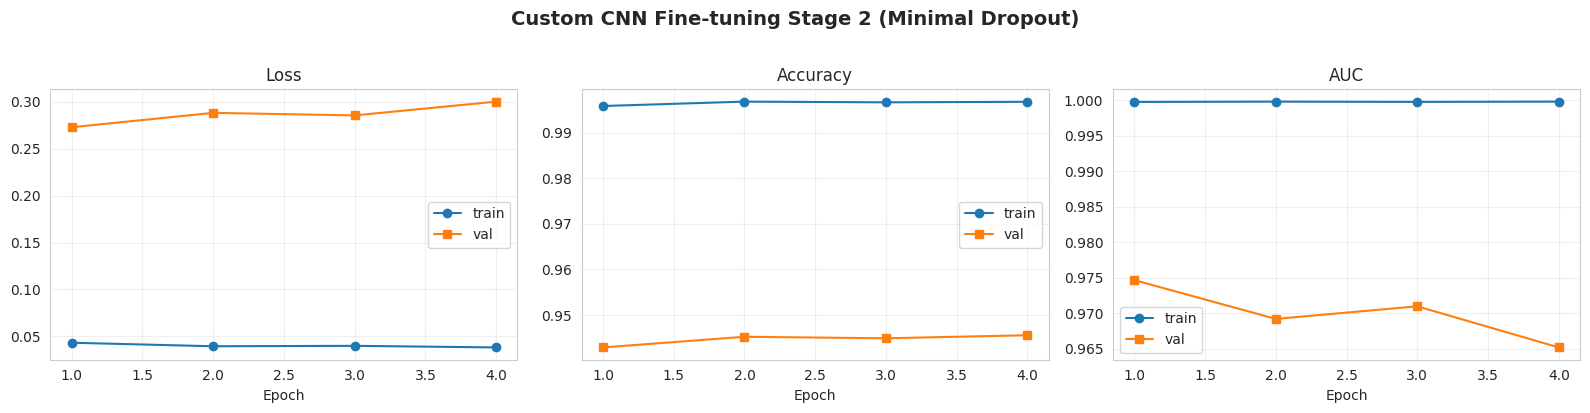

In [44]:
import matplotlib.pyplot as plt

def plot_history(hist, title="Training Curves"):
    h = hist.history
    epochs = range(1, len(h["loss"]) + 1)
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    axes[0].plot(epochs, h["loss"], label="train", marker='o')
    axes[0].plot(epochs, h["val_loss"], label="val", marker='s')
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(epochs, h["accuracy"], label="train", marker='o')
    axes[1].plot(epochs, h["val_accuracy"], label="val", marker='s')
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    axes[2].plot(epochs, h["auc"], label="train", marker='o')
    axes[2].plot(epochs, h["val_auc"], label="val", marker='s')
    axes[2].set_title("AUC")
    axes[2].set_xlabel("Epoch")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

plot_history(history_ft_stage2, "Custom CNN Fine-tuning Stage 2 (Minimal Dropout)")

📊 FINAL EVALUATION: Custom CNN Fine-tuning Stage 2 (Minimal Dropout)
94/94 ━━━━━━━━━━━━━━━━━━━━ 19s 190ms/step

🔹 SLICE-LEVEL RESULTS (Stage 2)
Accuracy: 94.93%

              precision    recall  f1-score   support

         GLI     0.9485    0.9710    0.9596      1860
        METS     0.9742    0.9802    0.9772       656
       OTHER     0.9144    0.8229    0.8662       480

    accuracy                         0.9493      2996
   macro avg     0.9457    0.9247    0.9343      2996
weighted avg     0.9487    0.9493    0.9485      2996



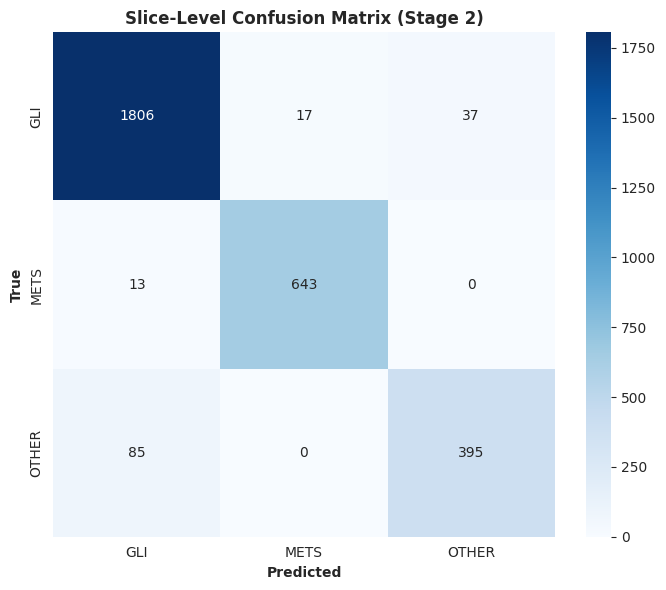

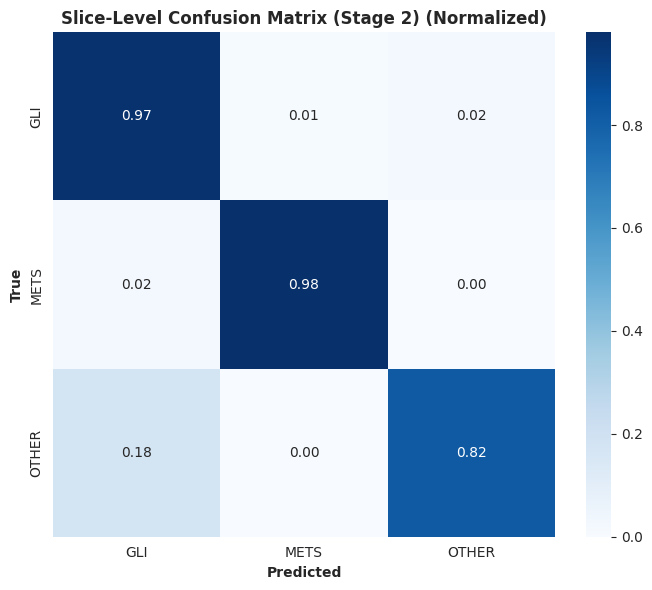


🔹 CASE-LEVEL RESULTS (Majority Vote - Stage 2)
Accuracy: 96.89%

              precision    recall  f1-score   support

         GLI     0.9635    0.9946    0.9788       186
        METS     0.9756    0.9756    0.9756        41
       OTHER     1.0000    0.8000    0.8889        30

    accuracy                         0.9689       257
   macro avg     0.9797    0.9234    0.9478       257
weighted avg     0.9697    0.9689    0.9678       257



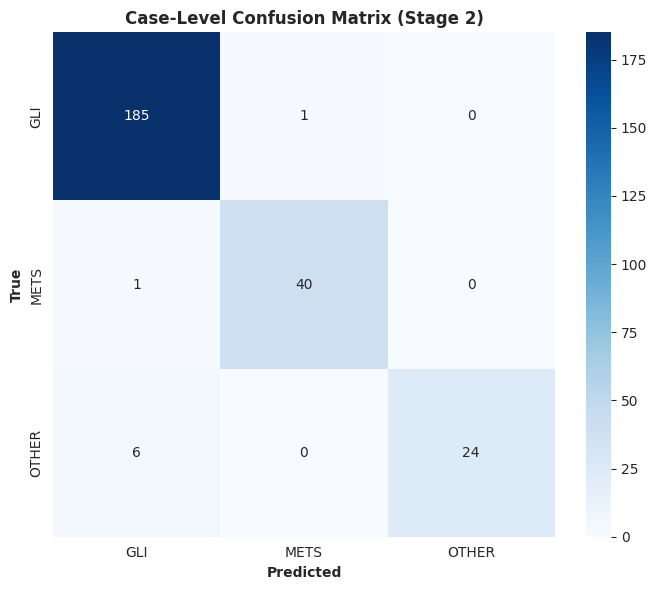

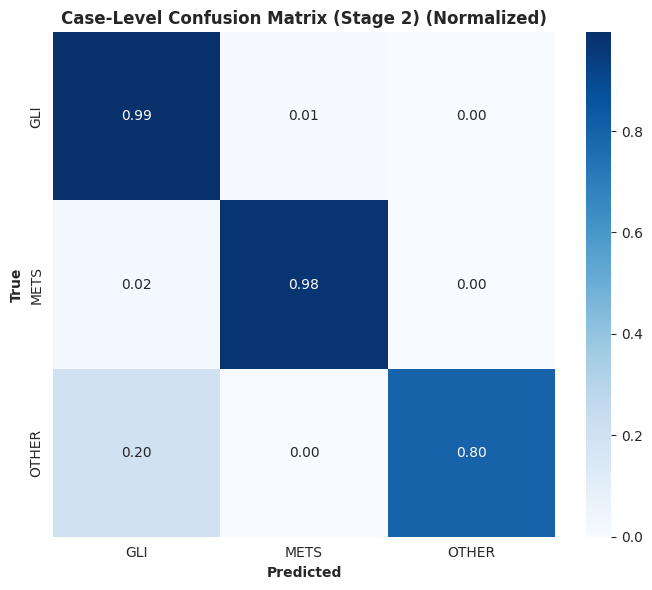

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

CLASS_NAMES = ["GLI", "METS", "OTHER"]

def plot_cm(y_true, y_pred, title, normalize=False):
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype("float") / (cm.sum(axis=1, keepdims=True) + 1e-12)
    
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm, annot=True,
        fmt=".2f" if normalize else "d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    plt.title(title + (" (Normalized)" if normalize else ""), fontweight="bold")
    plt.xlabel("Predicted", fontweight="bold")
    plt.ylabel("True", fontweight="bold")
    plt.tight_layout()
    plt.show()

def predict_with_metadata(model, gen):
    y_prob = model.predict(gen, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)
    
    case_keys = [ck for (ck, local_idx, lbl) in gen.samples]
    y_true = np.array([lbl for (ck, local_idx, lbl) in gen.samples], dtype=np.int32)
    return y_true, y_pred, y_prob, case_keys

def majority_vote(arr, n_classes=3):
    counts = np.bincount(arr, minlength=n_classes)
    top = counts.max()
    tied = np.where(counts == top)[0]
    return int(tied[0])

def case_level_vote(y_pred_slice, case_keys, clean_case_index):
    df = pd.DataFrame({"case_key": case_keys, "pred": y_pred_slice})
    y_pred_case = df.groupby("case_key")["pred"].apply(lambda s: majority_vote(s.values, n_classes=3))
    y_true_case = y_pred_case.index.to_series().apply(lambda ck: clean_case_index[ck]["class_label"])
    return y_true_case.values.astype(int), y_pred_case.values.astype(int)

print("=" * 70)
print("📊 FINAL EVALUATION: Custom CNN Fine-tuning Stage 2 (Minimal Dropout)")
print("=" * 70)

# Slice-level
y_true_slice, y_pred_slice, _, case_keys = predict_with_metadata(model_cnn_ft2, test_gen)

print("\n" + "="*70)
print("🔹 SLICE-LEVEL RESULTS (Stage 2)")
print("="*70)
print(f"Accuracy: {accuracy_score(y_true_slice, y_pred_slice)*100:.2f}%\n")
print(classification_report(y_true_slice, y_pred_slice, target_names=CLASS_NAMES, digits=4))

plot_cm(y_true_slice, y_pred_slice, "Slice-Level Confusion Matrix (Stage 2)", normalize=False)
plot_cm(y_true_slice, y_pred_slice, "Slice-Level Confusion Matrix (Stage 2)", normalize=True)

# Case-level
y_true_case, y_pred_case = case_level_vote(y_pred_slice, case_keys, clean_case_index)

print("\n" + "="*70)
print("🔹 CASE-LEVEL RESULTS (Majority Vote - Stage 2)")
print("="*70)
print(f"Accuracy: {accuracy_score(y_true_case, y_pred_case)*100:.2f}%\n")
print(classification_report(y_true_case, y_pred_case, target_names=CLASS_NAMES, digits=4))

plot_cm(y_true_case, y_pred_case, "Case-Level Confusion Matrix (Stage 2)", normalize=False)
plot_cm(y_true_case, y_pred_case, "Case-Level Confusion Matrix (Stage 2)", normalize=True)